# Lecture 0 — Part 2  
## The Intelligence System: How Different Forms of Intelligence Work Together

### From a ladder of methods to an architecture of intelligence

Lecture 0, Part 1 examined a deliberately simple but powerful idea: hold one financial problem constant and solve it with successive generations of analytical technology. Statistics described relationships. Econometrics estimated coefficients and probabilities. Classical machine learning learned nonlinear rules. Unsupervised learning discovered structure. Neural networks learned representations. Autoencoders compressed information into latent spaces. Generative AI interpreted meaning. Agentic systems organized multiple perspectives into judgment. The purpose was not to declare a winner. It was to show that successive technologies expanded the set of problems that machines could address.

Part 2 changes the question. In a real institution, we rarely choose exactly one generation of intelligence and discard all the others. A sophisticated system combines them. A modern autonomous vehicle is a useful analogy. Cameras, radar and other sensors perceive the environment. Specialized models recognize lanes, objects and hazards. Maps and localization tools establish context. Prediction models estimate what other road users may do. Planning systems evaluate possible trajectories. Control systems operate steering, acceleration and braking. Higher-level policies determine how cautious or assertive the vehicle should be. No single component deserves to be called “the intelligence.” Intelligence is an architecture that converts perception into analysis, judgment, action and feedback.

Finance increasingly has the same structure. An acquisition team searching for targets must read language, organize markets, estimate economics, classify strategic fit, value candidates, identify risk, reconcile conflicting evidence, apply governance constraints and finally produce an actionable shortlist. Some of these tasks are naturally handled by generative models. Others are better served by statistics, econometrics, clustering, neural networks, deterministic finance, optimization or explicit rules. The important question is therefore not “Where can we insert an LLM?” but “What form of intelligence belongs at each point in the institutional process?”

This notebook builds one such system. The mandate is fictional but realistic: a global payments company wants to identify acquisition candidates among a synthetic universe of firms. Each candidate has structured financial variables and an unstructured company dossier containing business descriptions, strategic commentary and operating signals. The acquisition team needs more than a ranking. It needs an explainable process showing why each candidate entered the funnel, what evidence was used, which models contributed, where judgment entered, what constraints were enforced and what action the system is actually permitted to recommend.

We will construct that process as a constellation of complementary intelligences. First, structured and unstructured evidence enters the system. Claude Haiku acts as a semantic perception layer, converting narrative dossiers into explicit strategic attributes. This is a natural use of a language model because the input contains meaning that is difficult to represent with fixed numerical columns alone. Next, clustering maps the competitive landscape without pretending that management already knows the correct market taxonomy. Regression estimates forward operating economics from measurable relationships. A neural classifier evaluates strategic fit using nonlinear interactions among company characteristics. Deterministic valuation and risk calculations then apply transparent financial mechanics. Claude returns later, not as a substitute for these calculations, but as a judgment layer that synthesizes heterogeneous evidence and articulates tensions among growth, fit, valuation and risk.

The architecture then adds something that is often missing from demonstrations of artificial intelligence: governance. A persuasive recommendation is not automatically an authorized recommendation. The system therefore applies explicit gates to leverage, valuation, data quality and evidence completeness. It records which components contributed to a conclusion and distinguishes analytical output from execution authority. In a real investment bank or corporation, the final step might initiate due diligence, request management approval, populate a pipeline, or prepare an investment-committee memorandum. It should not silently execute an acquisition.

This distinction gives us a more useful vocabulary for intelligence. **Perception** asks what is present in the environment. **Analysis** asks what patterns, relationships and projections can be extracted. **Prediction and classification** ask what is likely or what category an observation belongs to. **Judgment** asks how heterogeneous evidence should be interpreted in context. **Governance** asks what is permissible, sufficiently supported and auditable. **Execution** converts an approved decision into a bounded action. **Feedback** records outcomes so that the system and its operators can learn.

These layers can be sequential, but they are not merely a pipeline. They form a constellation. Judgment may request new perception. A governance gate may send a candidate back for additional analysis. A valuation anomaly may trigger another reading of the dossier. A model disagreement may be more informative than model consensus. Tools can be called repeatedly, and different forms of intelligence can operate in parallel. The architecture is therefore closer to an institution than to a single model.

This also clarifies what generative AI changes. LLMs are extraordinary interfaces to language, context and flexible reasoning, but they do not eliminate the need for older analytical intelligence. A regression coefficient remains useful when we want an interpretable conditional relationship. Clustering remains useful when we want data-driven segmentation. A neural classifier remains useful when repeated labeled examples define a stable prediction problem. A discounted cash-flow calculation should not become a prose hallucination simply because an LLM is available. Deterministic controls remain essential when an action crosses an institutional boundary.

The central lesson of Lecture 0, Part 2 is therefore simple: **modern intelligence is compositional**. The institution becomes more capable not merely by installing a more powerful model, but by designing the relationships among models, tools, data, rules, people and actions. The quality of the system depends on architecture: what sees, what calculates, what judges, what checks, what acts and what learns.

By the end of the notebook, students should be able to look at an AI proposal and ask a more sophisticated set of questions. What is the perception layer? Which analytical methods are appropriate to the data? Where does semantic reasoning add value? Which outputs must be deterministic? How is disagreement preserved? What authority does the model have? Where are the governance gates? What gets logged? What happens after the recommendation? And, critically, who remains accountable?

The objective is not to automate an M&A department in ten cells. It is to make the architecture visible. Once that architecture is visible, the same framework can be transferred to credit, trading, insurance, compliance, treasury, supervision, research and corporate strategy. Intelligence is not a model. It is a governed system that turns evidence into action.

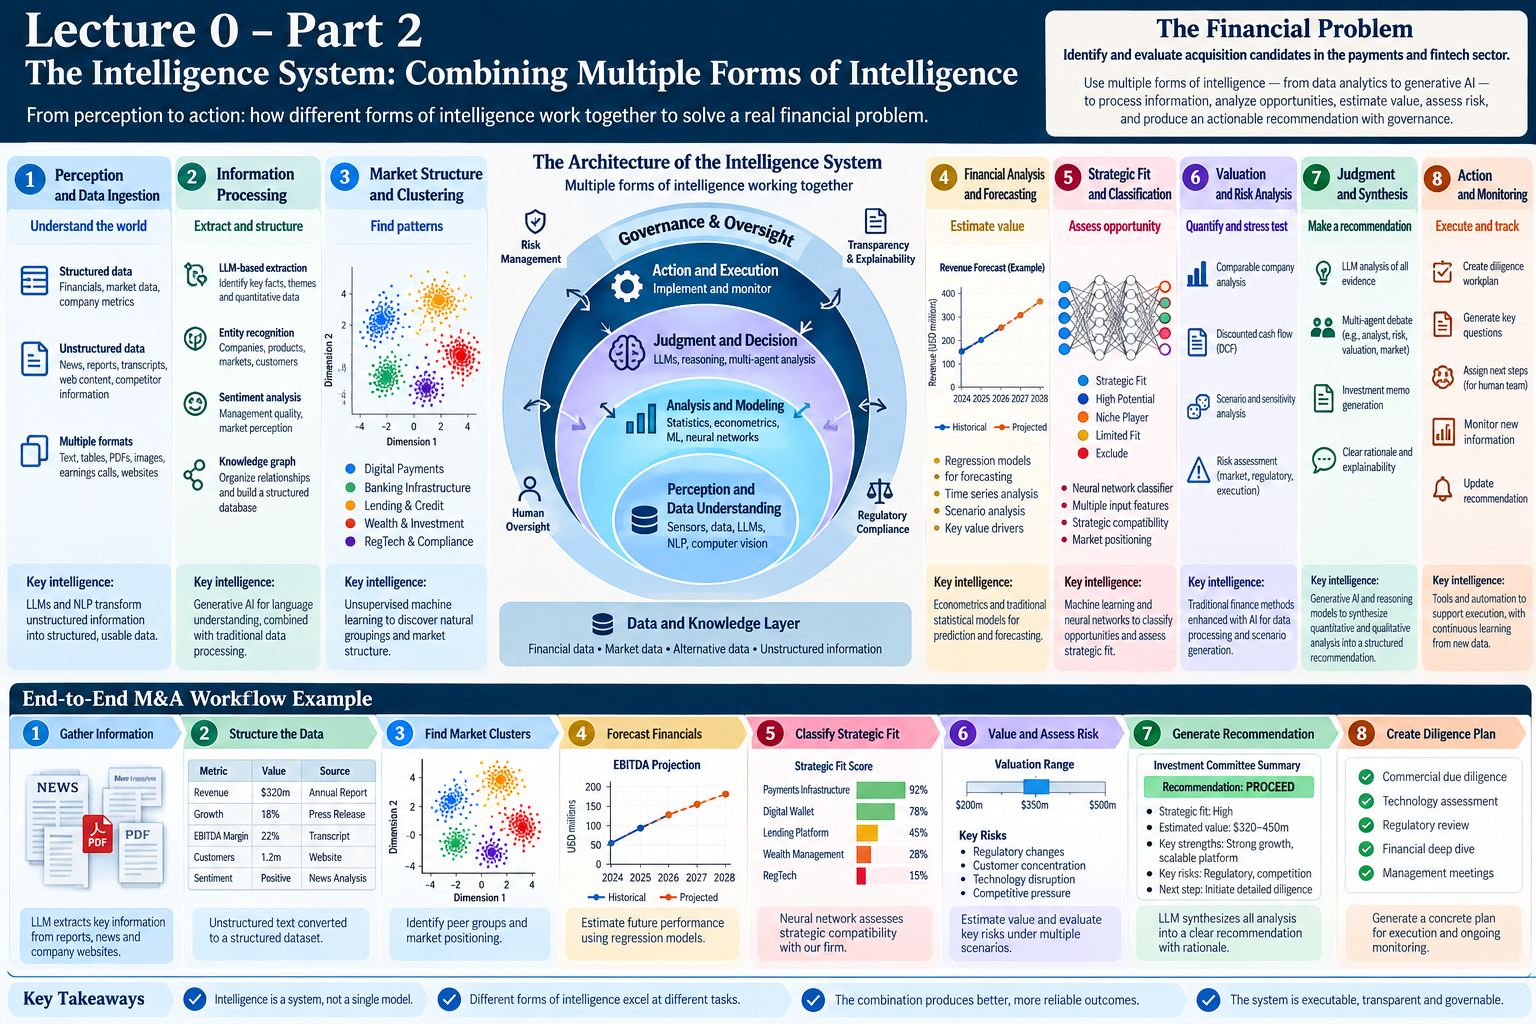

## Cell 1 — Build the M&A environment: the world before the intelligence

Every intelligent system begins with an environment. Before discussing models, agents or language, we need to specify what the institution can observe and what decision it is trying to make. Our fictional acquirer is **AtlasPay**, a global payments company seeking acquisition candidates that can expand its capabilities in merchant software, fraud technology, cross-border infrastructure and embedded finance. The universe contains synthetic companies rather than real securities or recommendations. This keeps the notebook reproducible and lets us control the relationships embedded in the data.

Each company has structured financial information—growth, margins, leverage, recurring revenue, valuation, geographic reach, customer concentration and other variables—but also a short narrative dossier. That distinction is crucial. Traditional quantitative systems are comfortable with columns. Real institutions also receive annual reports, management commentary, product descriptions, research notes and due-diligence material. Intelligence must therefore perceive both numbers and meaning.

This cell creates the common evidence base and the acquisition mandate. It also establishes a hidden “ground truth” strategic-fit label used later only to train and evaluate the neural classifier. The label is generated from a nonlinear synthetic rule; it is not presented as objective truth about real companies. The exercise is deliberately constructed so that no single variable determines attractiveness.

Notice the architectural principle: the data layer is not itself the intelligence. Sensors in an autonomous vehicle do not decide how to drive; they make the environment observable. Likewise, financial databases and documents create the observable world for the acquisition system. Later components will transform these observations differently.

As you inspect the sample companies, ask which attributes are directly measurable, which require interpretation, and which are consequences of a model. Keeping those categories separate is one of the foundations of transparent AI architecture.

In [10]:
# @title
# Cell 1 — Synthetic acquisition universe and mandate
import sys, subprocess, importlib.util, json, re, time, random, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_absolute_error, classification_report, ConfusionMatrixDisplay

np.random.seed(42); random.seed(42)
N=240
themes=np.array(["Merchant Software","Fraud & Identity","Cross-Border","Embedded Finance","Legacy Processing"])
regions=np.array(["North America","Latin America","Europe","Asia-Pacific"])
names=[f"Target-{i:03d}" for i in range(1,N+1)]
theme=np.random.choice(themes,N,p=[.25,.18,.20,.20,.17])
region=np.random.choice(regions,N)
growth=np.clip(np.random.normal(18,10,N),-5,55)
margin=np.clip(np.random.normal(20,9,N),-5,45)
recurring=np.clip(np.random.normal(62,22,N),5,98)
leverage=np.clip(np.random.gamma(2,0.7,N),0,5)
concentration=np.clip(np.random.normal(24,13,N),4,70)
revenue=np.exp(np.random.normal(np.log(450),.7,N))
multiple=np.clip(3.5 + growth/12 + recurring/45 + np.random.normal(0,1.2,N),1.5,14)
geo_comp=np.isin(region,["Latin America","Asia-Pacific"]).astype(int)
adj=np.isin(theme,["Merchant Software","Fraud & Identity","Cross-Border"]).astype(int)
latent=0.045*growth+0.028*recurring+1.0*adj+.65*geo_comp-.55*leverage-.018*concentration+np.random.normal(0,.65,N)
fit=(latent>np.quantile(latent,.57)).astype(int)
next_margin=np.clip(margin + .12*growth + .035*recurring - 1.3*leverage + np.random.normal(0,3,N),-5,55)

df=pd.DataFrame(dict(company=names,theme=theme,region=region,revenue_m=revenue,growth_pct=growth,
 margin_pct=margin,recurring_pct=recurring,leverage_x=leverage,customer_concentration_pct=concentration,
 valuation_multiple_x=multiple,geo_complement=geo_comp,product_adjacency=adj,strategic_fit_label=fit,
 next_margin_pct=next_margin))
df["dossier"]=df.apply(lambda r: f"{r.company} operates in {r.theme.lower()} across {r.region}. "
 f"Management describes {r.growth_pct:.0f}% revenue growth, {r.recurring_pct:.0f}% recurring revenue "
 f"and expansion initiatives. The business emphasizes scalable technology, enterprise clients and "
 f"{'geographic expansion' if r.geo_complement else 'depth in established markets'}.",axis=1)
display(Markdown("### AtlasPay acquisition mandate\nIdentify targets that expand payments capabilities while balancing strategic fit, forward economics, valuation and risk."))
display(df.head(8))


### AtlasPay acquisition mandate
Identify targets that expand payments capabilities while balancing strategic fit, forward economics, valuation and risk.

,company,theme,region,revenue_m,growth_pct,margin_pct,recurring_pct,leverage_x,customer_concentration_pct,valuation_multiple_x,geo_complement,product_adjacency,strategic_fit_label,next_margin_pct,dossier
0,Target-001,Fraud & Identity,Asia-Pacific,249.967511,33.860168,14.036386,98.000000,1.221388,7.141185,9.852288,1,1,1,19.174278,Target-001 operates in fraud & identity across...
1,Target-002,Legacy Processing,Latin America,302.944082,5.621845,25.135388,59.886682,0.674251,22.773167,4.761805,1,0,0,26.048162,Target-002 operates in legacy processing acros...
2,Target-003,Embedded Finance,North America,337.562785,39.330334,13.130668,87.284013,2.177042,22.883388,7.186174,0,0,0,13.204427,Target-003 operates in embedded finance across...
3,Target-004,Cross-Border,Latin America,282.971997,-1.520878,3.756061,46.530119,1.839952,34.564963,4.371090,1,1,1,2.480864,Target-004 operates in cross-border across Lat...
4,Target-005,Merchant Software,North America,108.687400,16.482149,5.352118,61.230253,2.808062,31.512837,5.552938,0,1,0,7.315010,Target-005 operates in merchant software acros...
5,Target-006,Merchant Software,Latin America,767.978205,23.883172,20.432765,98.000000,1.354502,24.396225,5.838617,1,1,1,23.811742,Target-006 operates in merchant software acros...
6,Target-007,Merchant Software,Europe,1084.841912,20.809919,22.337503,48.206725,3.543675,4.604830,6.594530,0,1,0,23.176507,Target-007 operates in merchant software acros...
7,Target-008,Legacy Processing,Asia-Pacific,155.451428,11.773005,11.861150,98.000000,1.354813,30.427764,6.977925,1,0,0,12.349481,Target-008 operates in legacy processing acros...


## Cell 2 — Semantic perception: use the LLM where language actually matters

The first active intelligence layer is **perception**. In an autonomous vehicle, perception converts camera pixels and sensor returns into useful concepts such as pedestrian, lane boundary or obstacle. In our M&A system, the equivalent challenge is converting narrative company dossiers into structured strategic signals. A description may say that a company provides “API-based merchant orchestration across fragmented Latin American acquiring markets.” A human banker immediately extracts concepts: payments infrastructure, cross-border relevance, software orientation and geographic complementarity. A conventional numerical table does not automatically contain those meanings.

Claude Haiku 4.5 is therefore used here as a semantic sensor. It receives only synthetic dossier text and returns a tightly defined JSON object describing business model, strategic theme, geographic signal, recurring-revenue signal and potential strategic rationale. The LLM is not asked to value the company, rank the target or authorize anything. Its role is bounded: transform unstructured language into structured observations.

The API key is read from the Colab Secrets facility under `ANTHROPIC_API_KEY`; it is never printed or written into the notebook. The model is `claude-haiku-4-5-20251001`, matching Part 1. We use a non-zero temperature and validate the returned JSON. A failed live call raises an explicit error rather than silently pretending that a heuristic was Claude.

For classroom cost and speed, the live demonstration perceives a selected subset of dossiers. The remaining synthetic records already contain numerical variables used by later methods. In a production architecture, semantic extraction could be batched, cached, versioned and independently reviewed.

The important lesson is placement. Generative AI is powerful here because the problem is semantic. It is not being used merely because it is fashionable. Architecture improves when each form of intelligence is assigned the problem structure for which it is appropriate.

In [11]:
# @title
# ============================================================
# CELL 2 — CLAUDE SEMANTIC PERCEPTION FROM UNSTRUCTURED DOSSIERS
# Lecture 0 · Part II
#
# Claude Haiku 4.5:
#   claude-haiku-4-5-20251001
#
# IMPORTANT:
#   1. NO temperature parameter.
#   2. NO "return JSON only" prompt engineering.
#   3. NO regex extraction of JSON.
#   4. NO json.loads() of free-form model text.
#   5. Use Anthropic structured outputs through client.messages.parse().
# ============================================================

import sys
import subprocess
import importlib.util
import importlib.metadata
import pandas as pd


# ------------------------------------------------------------
# 1. INSTALL / LOAD CURRENT ANTHROPIC SDK
# ------------------------------------------------------------

if importlib.util.find_spec("anthropic") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-U",
        "anthropic"
    ])

from google.colab import userdata
from anthropic import Anthropic
from pydantic import BaseModel, Field


print(
    "Anthropic library version:",
    importlib.metadata.version("anthropic")
)


# ------------------------------------------------------------
# 2. COLAB SECRET
# ------------------------------------------------------------

try:
    api_key = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    raise RuntimeError(
        "Add ANTHROPIC_API_KEY in Colab Secrets "
        "and enable notebook access."
    ) from None


if not api_key:
    raise RuntimeError(
        "ANTHROPIC_API_KEY is empty."
    )


# ------------------------------------------------------------
# 3. EXACT MODEL
# ------------------------------------------------------------

MODEL = "claude-haiku-4-5-20251001"


client = Anthropic(
    api_key=api_key,
    timeout=60.0,
    max_retries=2
)

# Do not retain the raw key in the notebook namespace.
del api_key


print(f"Claude model: {MODEL}")


# ------------------------------------------------------------
# 4. DEFINE THE STRUCTURED OUTPUT SCHEMA
#
# This is the important correction.
#
# Claude is not being asked to "write JSON".
# The SDK requests a structured response conforming to this
# schema and returns a validated Python/Pydantic object.
# ------------------------------------------------------------

class SemanticPerception(BaseModel):

    business_model: str = Field(
        description=(
            "Concise description of the company's business model "
            "using only information contained in the dossier."
        )
    )

    strategic_theme: str = Field(
        description=(
            "The principal strategic theme visible in the dossier."
        )
    )

    geography_signal: str = Field(
        description=(
            "What the dossier indicates about geographic position "
            "or expansion."
        )
    )

    recurring_revenue_signal: str = Field(
        description=(
            "What can legitimately be inferred about recurring "
            "revenue from the dossier."
        )
    )

    strategic_rationale: str = Field(
        description=(
            "A concise description of why the company might be "
            "strategically relevant to AtlasPay. This is not a "
            "recommendation and must not introduce facts absent "
            "from the dossier."
        )
    )


# ------------------------------------------------------------
# 5. SEMANTIC-PERCEPTION FUNCTION
#
# Notice what is NOT here:
#
#     temperature=...
#
# There is deliberately no temperature argument.
# ------------------------------------------------------------

def perceive_dossier(dossier):

    prompt = f"""
You are the semantic-perception layer of a fictional M&A teaching
system for AtlasPay.

Your task is PERCEPTION, not investment judgment.

Read the company dossier and extract its economically relevant
meaning.

STRICT RULES:

- Use only information contained in the dossier.
- Do not invent facts.
- Do not estimate valuation.
- Do not rank the company.
- Do not recommend an acquisition.
- Do not make a final investment decision.
- Distinguish what the dossier actually says from what is merely
  suggested by its language.
- Keep each field concise and analytically useful.

COMPANY DOSSIER

{dossier}
"""

    try:

        response = client.messages.parse(

            model=MODEL,

            max_tokens=900,

            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],

            output_format=SemanticPerception
        )

    except Exception as e:

        raise RuntimeError(
            "Claude Haiku 4.5 structured-output call failed.\n"
            f"{type(e).__name__}: {e}"
        ) from e


    # --------------------------------------------------------
    # Anthropic SDK returns the validated structured object.
    # No regex.
    # No Markdown-fence stripping.
    # No json.loads().
    # --------------------------------------------------------

    parsed = response.parsed_output

    if parsed is None:
        raise RuntimeError(
            "Claude returned no parsed structured output."
        )

    return parsed


# ------------------------------------------------------------
# 6. SELECT A SMALL TEACHING SAMPLE
# ------------------------------------------------------------

sample = (
    df
    .sample(
        6,
        random_state=7
    )
    .copy()
)


# ------------------------------------------------------------
# 7. RUN SEMANTIC PERCEPTION
# ------------------------------------------------------------

semantic = {}


for _, row in sample.iterrows():

    print(
        f"Reading dossier: {row.company}"
    )

    result = perceive_dossier(
        row.dossier
    )

    semantic[row.company] = (
        result.model_dump()
    )


# ------------------------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------------------------

semantic_df = (
    pd.DataFrame
    .from_dict(
        semantic,
        orient="index"
    )
)


semantic_df.index.name = "company"


display(
    semantic_df
)


# ------------------------------------------------------------
# 9. PEDAGOGICAL MESSAGE
# ------------------------------------------------------------

print(
    "\nSEMANTIC PERCEPTION COMPLETE\n"
    "Claude has converted unstructured company narratives into "
    "structured strategic signals.\n"
    "It has NOT ranked the targets, valued them, forecast their "
    "economics, or made an acquisition recommendation."
)

Anthropic library version: 1.11.0
Claude model: claude-haiku-4-5-20251001
Reading dossier: Target-081
Reading dossier: Target-130
Reading dossier: Target-004
Reading dossier: Target-206
Reading dossier: Target-149
Reading dossier: Target-191


,business_model,strategic_theme,geography_signal,recurring_revenue_signal,strategic_rationale
company,,,,,
Target-081,Legacy processing services provider serving en...,Technology scalability and geographic expansio...,Current operations in Asia-Pacific with stated...,37% of revenue is explicitly stated as recurri...,"Target-081's emphasis on enterprise clients, r..."
Target-130,Target-130 provides cross-border services acro...,Geographic expansion combined with technology ...,Operates in Asia-Pacific region with stated ex...,"73% of revenue is recurring, indicating strong...",Target-130's focus on cross-border operations ...
Target-004,Cross-border payment or transaction processing...,Geographic expansion and technology scalabilit...,Active operations across Latin America with ex...,47% of revenue is recurring; the majority (53%...,Cross-border Latin American operations could r...
Target-206,SaaS/software-as-a-service for merchants opera...,Geographic and customer segment expansion with...,Operating in Latin America with stated expansi...,"Management reports 98% recurring revenue, indi...",The company's merchant software platform with ...
Target-149,Target-149 provides merchant software solution...,Emphasis on scalable technology infrastructure...,Primary presence in established European marke...,Approximately 55% of revenue is recurring in n...,A European merchant software provider with sig...
Target-191,Software platform providing merchant services ...,Building scalable merchant software technology...,Operations and expansion focus confined to Nor...,34% of revenue is explicitly recurring; 66% ap...,Target-191's enterprise merchant software plat...



SEMANTIC PERCEPTION COMPLETE
Claude has converted unstructured company narratives into structured strategic signals.
It has NOT ranked the targets, valued them, forecast their economics, or made an acquisition recommendation.


### Semantic Perception with LLM

**What was done in Cell 2?**

In Cell 2, we leveraged Claude Haiku 4.5 to perform **semantic perception** on a selection of unstructured company dossiers. This involved setting up the Anthropic API client, defining a precise structured output schema using Pydantic, and then calling the LLM with each company's dossier.

**What was achieved?**

This cell achieved the transformation of qualitative, narrative text (company dossiers) into structured, explicit strategic attributes. Instead of relying solely on predefined numerical columns, we extracted meaningful insights from the written descriptions. This provides a rich, interpretable, and machine-readable representation of each company's strategic profile.

**What was the input and what was the output for the LLM?**

*   **Input to the LLM:** The input was the `dossier` text for each company, which is an unstructured natural language description of its operations, growth, recurring revenue, and strategic focus.
*   **Output from the LLM:** The output was a tightly defined JSON object (parsed into a Pydantic object in Python), containing the following structured strategic attributes:
    *   `business_model`: A concise description of the company's business model.
    *   `strategic_theme`: The principal strategic theme.
    *   `geography_signal`: Information about geographic position or expansion.
    *   `recurring_revenue_signal`: Inferred details about recurring revenue.
    *   `strategic_rationale`: A concise description of the company's potential strategic relevance to AtlasPay.

**What was the task we gave the LLM?**

The LLM was tasked to act specifically as a "semantic-perception layer." Its role was narrowly defined: to read the company dossier and extract its economically relevant meaning. Crucially, it was given strict rules *not* to invent facts, estimate valuation, rank the company, recommend an acquisition, or make a final investment decision. Its intelligence function was bounded to perception and factual extraction from text.

**How does this contribute to the final objective?**

This semantic perception layer is the first critical step in building a comprehensive intelligence system for M&A. It provides the initial structured "perception" of acquisition candidates by converting qualitative information into objective, extracted signals. These structured signals, derived from rich textual data, are then fed into subsequent analytical layers (such as clustering, regression, and neural classification) to enable a multi-modal and more informed assessment of potential acquisition targets for AtlasPay. It ensures that the system incorporates insights from both structured and unstructured data sources from the very beginning.

## Cell 3 — Market structure: clustering as a different kind of intelligence

After perception comes organization. An acquisition team rarely begins with a perfectly agreed taxonomy of the market. Companies can combine software, payments, fraud, lending, identity and infrastructure in ways that make traditional sector labels inadequate. **Unsupervised learning** is useful precisely because it can reveal structure without requiring a predefined target label.

This cell standardizes selected financial and operating characteristics and applies K-means clustering. Principal-component analysis is used only to display the resulting structure in two dimensions. The cluster number has no intrinsic economic meaning. Cluster 0 is not “better” than Cluster 1. Instead, we inspect the average characteristics of each group and ask what economic interpretation a banker might attach to it.

This is a very different intelligence function from Claude's semantic perception. The LLM reads meaning in language. Clustering discovers geometric regularities in numerical feature space. Neither subsumes the other. In fact, their disagreement can be useful: a company described in language as an infrastructure provider may numerically resemble high-growth software firms. That tension can trigger further investigation.

The autonomous-driving analogy is again useful. Object recognition and road mapping are separate capabilities even though both contribute to understanding the environment. Likewise, market segmentation and narrative interpretation are complementary perceptions of the acquisition landscape.

The cell also demonstrates an important governance principle: unsupervised output should not be over-interpreted. Clusters depend on feature choice, scaling and the specified number of groups. They are analytical artifacts, not natural laws. A transparent system exposes these choices rather than hiding them behind a polished label.

At this stage we have already combined two kinds of intelligence: semantic interpretation of unstructured information and statistical discovery of structure. The next cells add forward-looking estimation and nonlinear classification.

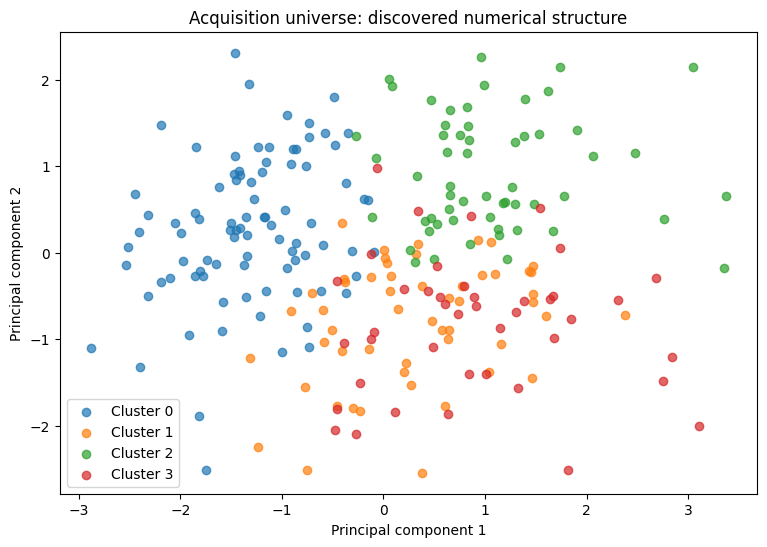

,growth_pct,margin_pct,recurring_pct,leverage_x,customer_concentration_pct,valuation_multiple_x
cluster,,,,,,
0,10.60,21.07,56.75,1.08,30.15,5.23
1,21.44,14.80,60.27,1.16,11.94,6.58
2,23.22,22.10,79.03,1.05,29.03,7.81
3,23.21,18.39,67.62,3.06,23.60,6.72


In [12]:
# @title
# Cell 3 — Unsupervised market structure
features=["growth_pct","margin_pct","recurring_pct","leverage_x","customer_concentration_pct","valuation_multiple_x"]
X=StandardScaler().fit_transform(df[features])
km=KMeans(n_clusters=4,random_state=42,n_init=20)
df["cluster"]=km.fit_predict(X)
pca=PCA(n_components=2,random_state=42)
Z=pca.fit_transform(X)
plt.figure(figsize=(9,6))
for c in sorted(df.cluster.unique()):
    m=df.cluster==c
    plt.scatter(Z[m,0],Z[m,1],label=f"Cluster {c}",alpha=.7)
plt.xlabel("Principal component 1"); plt.ylabel("Principal component 2")
plt.title("Acquisition universe: discovered numerical structure"); plt.legend(); plt.show()
display(df.groupby("cluster")[features].mean().round(2))


## Cell 4 — Econometric projection: estimate rather than narrate

Acquisitions are forward-looking decisions. Strategic fit matters, but the buyer also needs a disciplined view of future economics. This cell uses a regression model to estimate next-period EBITDA margin from observable company characteristics. The purpose is not to claim that a simple synthetic regression is a real forecasting model. It is to demonstrate where econometric intelligence belongs inside a broader AI system.

Regression provides something an LLM should not be asked to invent: a reproducible numerical mapping between specified variables and an outcome. We split the synthetic data into training and test samples, fit the model, report out-of-sample error, inspect coefficients and generate a forward margin estimate for every candidate. The prediction becomes one piece of evidence for later judgment.

This illustrates why “AI system” should not be translated as “LLM everywhere.” If the task is stable, tabular and numerical, a conventional estimator may be cheaper, faster, more reproducible and easier to audit. The LLM can later interpret what the estimate means in context, but it should not replace a transparent estimator merely to make the architecture appear more modern.

At the same time, econometric outputs have limitations. A coefficient is conditional on the specification and synthetic data-generating process. Prediction error remains. Correlation does not automatically imply causation. Regime changes can invalidate historical relationships. The system should therefore carry the forecast as evidence, not as certainty.

Think of this as the prediction module of the autonomous car: estimating where an object may move is different from recognizing the object and different again from deciding how the vehicle should respond. Financial intelligence benefits from the same separation of functions.

In [13]:
# @title
# Cell 4 — Econometric projection of forward operating economics
reg_features=["growth_pct","margin_pct","recurring_pct","leverage_x","customer_concentration_pct"]
Xr=df[reg_features]; yr=df["next_margin_pct"]
Xtr,Xte,ytr,yte=train_test_split(Xr,yr,test_size=.25,random_state=42)
reg=LinearRegression().fit(Xtr,ytr)
pred=reg.predict(Xte)
print("Held-out MAE:",round(mean_absolute_error(yte,pred),2),"margin points")
display(pd.Series(reg.coef_,index=reg_features,name="coefficient").to_frame().round(3))
df["projected_margin_pct"]=reg.predict(Xr)
display(df[["company","margin_pct","projected_margin_pct"]].head(10).round(2))


Held-out MAE: 2.19 margin points


,coefficient
growth_pct,0.086
margin_pct,0.982
recurring_pct,0.043
leverage_x,-1.138
customer_concentration_pct,0.038


,company,margin_pct,projected_margin_pct
0,Target-001,14.04,18.92
1,Target-002,25.14,26.97
2,Target-003,13.13,17.56
3,Target-004,3.76,3.91
4,Target-005,5.35,6.44
5,Target-006,20.43,24.86
6,Target-007,22.34,21.07
7,Target-008,11.86,15.63
8,Target-009,25.75,29.63
9,Target-010,5.05,8.51


### Econometric Projection of Forward Operating Economics

**What was done in Cell 4?**

In Cell 4, we implemented an **econometric projection** using a Linear Regression model. This involved defining a set of features (`reg_features`), splitting the dataset into training and test sets, training the linear regression model on the training data, evaluating its performance on the held-out test data, and then using the trained model to predict a 'projected_margin_pct' for all companies in the dataset.

**What was achieved?**

This cell achieved the ability to **estimate forward operating economics** (specifically, next-period EBITDA margin) based on quantifiable characteristics of the companies. It provides a structured, reproducible, and interpretable numerical forecast, moving beyond qualitative descriptions to a quantitative projection.

**What was the input and what was the output?**

*   **Input to the model:** The input consisted of structured numerical features from the `df` DataFrame: `growth_pct`, `margin_pct`, `recurring_pct`, `leverage_x`, and `customer_concentration_pct`.
*   **Output from the model:** The output was a `projected_margin_pct` for each company, representing a numerical estimate of their future EBITDA margin. The cell also produced metrics like the Held-out Mean Absolute Error (MAE) and the coefficients of the regression features, indicating their influence on the projected margin.

**What was the task we gave the model (not an LLM)?**

Unlike Cell 2, Cell 4 did **not** use an LLM. The task given to the Linear Regression model was to learn a linear relationship between the input financial and operating characteristics (`reg_features`) and the target variable (`next_margin_pct`). The objective was to create a transparent and reproducible numerical mapping that can forecast future economics.


### Collective Contribution of Cells 2, 3, and 4: Building a Multi-Modal Evidence Base

Cells 2, 3, and 4 work in concert to establish a foundational, multi-modal evidence base for each potential acquisition candidate. Individually, they address distinct aspects of intelligence, but together, they create a rich, comprehensive profile that moves beyond any single analytical lens.

*   **Cell 2 (Semantic Perception):** This cell acts as the **qualitative intelligence layer**. By using an LLM to extract structured strategic attributes from unstructured company dossiers, it transforms narrative text into machine-readable signals. This provides a deep understanding of a company's business model, strategic themes, geographic reach, and recurring revenue potential, which cannot be captured by numerical data alone. It answers: *What is the company's strategic story and intent?*

*   **Cell 3 (Market Structure):** This cell provides the **contextual intelligence layer**. Through unsupervised clustering on standardized financial and operating characteristics, it discovers latent market structures and segments companies into economically meaningful groups. This allows AtlasPay to understand the competitive landscape and identify how potential targets fit within or disrupt existing market definitions, without relying on predefined categories. It answers: *How does this company numerically relate to others in the market?*

*   **Cell 4 (Econometric Projection):** This cell contributes the **quantitative forecasting intelligence layer**. By applying linear regression to project future EBITDA margins, it provides a disciplined, reproducible estimate of each company's forward operating economics. This numerical projection offers a crucial objective view of financial potential, complementing the qualitative and structural insights. It answers: *What are the objective, quantifiable financial prospects of this company?*

**Contribution to the Final Objective:**

The main objective of this notebook is to build an M&A intelligence system that identifies acquisition candidates by balancing strategic fit, forward economics, valuation, and risk. Cells 2, 3, and 4 collectively lay the groundwork for this by:

1.  **Enriching the Data:** They move beyond simple tabular data to incorporate semantic meaning and discovered market structures, creating a much richer dataset for subsequent analysis.
2.  **Providing Diverse Perspectives:** By employing different forms of intelligence (LLM-based semantic extraction, unsupervised clustering, and econometric regression), they offer varied, yet complementary, insights into each company.
3.  **Informing Downstream Layers:** The structured outputs from these cells (semantic attributes, cluster assignments, and projected margins) are essential inputs for the subsequent stages, such as neural classification of strategic fit (Cell 5), deterministic valuation (Cell 6), and ultimately, the LLM-based judgment layer (Cell 7). This multi-faceted evidence allows for a more nuanced and robust assessment, ensuring that decisions are based on a holistic understanding rather than a single, potentially biased, metric.

## Cell 5 — Neural classification: learn nonlinear strategic fit

The next layer asks a classification question: based on repeated examples, does a candidate exhibit the pattern associated with high strategic fit for AtlasPay? The synthetic data contain a hidden label generated from nonlinear interactions among recurring revenue, product adjacency, geographic complementarity, growth, leverage and customer concentration. A multilayer neural network is trained to recover that pattern.

This is a useful place for neural machine learning because the problem is neither open-ended language interpretation nor a transparent linear projection. It is a repeated classification task with labeled examples and interactions among features. The model returns a probability-like strategic-fit score that can be compared across candidates.

The pedagogical point is not that neural networks are always superior. A tree ensemble might perform as well or better. Rather, this cell gives the architecture another specialized form of intelligence: learned nonlinear classification. We evaluate it on a held-out test set and display a confusion matrix and classification metrics. That makes performance visible rather than simply trusting the model because it is called “neural.”

This also creates an instructive contrast with the LLM. Claude may read a dossier and identify a strategic theme. The neural classifier cannot explain prose, but it can consistently process the same feature schema across hundreds or millions of observations. In an institutional system, these capabilities can reinforce or challenge one another.

If semantic perception says “strong strategic adjacency” but the classifier assigns low fit, the correct response is not necessarily to average the scores. The disagreement may indicate missing data, a novel business model, a distribution shift or a flawed model. Intelligent architecture preserves such tensions for judgment rather than prematurely collapsing them into a single number.

              precision    recall  f1-score   support

           0      0.574     0.912     0.705        34
           1      0.500     0.115     0.188        26

    accuracy                          0.567        60
   macro avg      0.537     0.514     0.446        60
weighted avg      0.542     0.567     0.480        60



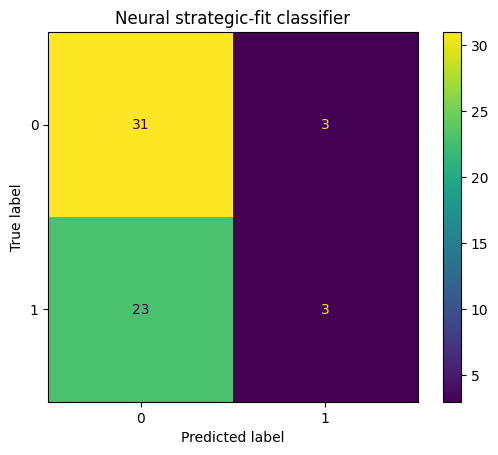

In [14]:
# @title
# Cell 5 — Neural strategic-fit classifier
clf_features=["growth_pct","margin_pct","recurring_pct","leverage_x","customer_concentration_pct",
              "valuation_multiple_x","geo_complement","product_adjacency"]
Xs=StandardScaler()
Xn=Xs.fit_transform(df[clf_features]); yn=df["strategic_fit_label"]
Xtr,Xte,ytr,yte=train_test_split(Xn,yn,test_size=.25,random_state=42,stratify=yn)
mlp=MLPClassifier(hidden_layer_sizes=(16,8),max_iter=1500,random_state=42,early_stopping=True).fit(Xtr,ytr)
yp=mlp.predict(Xte)
print(classification_report(yte,yp,digits=3))
ConfusionMatrixDisplay.from_predictions(yte,yp); plt.title("Neural strategic-fit classifier"); plt.show()
df["neural_fit_score"]=mlp.predict_proba(Xn)[:,1]


### Neural Classification of Strategic Fit

**What was done in Cell 5?**

In Cell 5, we developed a **neural classification model** (a Multilayer Perceptron, or MLP) to assess the strategic fit of each company for AtlasPay. This involved:
1.  **Feature Selection:** Identifying a set of features (`clf_features`) relevant for strategic fit.
2.  **Data Standardization:** Scaling the features using `StandardScaler` to ensure consistent input to the neural network.
3.  **Data Splitting:** Dividing the dataset into training and test sets, maintaining class balance with `stratify=yn`.
4.  **Model Training:** Fitting the `MLPClassifier` to the training data, with early stopping to prevent overfitting.
5.  **Model Evaluation:** Reporting performance metrics (precision, recall, f1-score, accuracy) and visualizing a confusion matrix on the held-out test set.
6.  **Prediction:** Generating a `neural_fit_score` (probability-like score) for all companies based on the trained model.

**What was achieved?**

This cell achieved a **nonlinear classification of strategic fit** based on learned patterns from labeled examples. It provides a quantifiable, comparable score for each candidate, indicating its likelihood of having high strategic fit according to the hidden, synthetic ground truth. This moves beyond simple thresholds or linear relationships, capturing complex interactions among features.

**What was the input and what was the output?**

*   **Input to the model:** The input consisted of standardized numerical features, including `growth_pct`, `margin_pct`, `recurring_pct`, `leverage_x`, `customer_concentration_pct`, `valuation_multiple_x`, `geo_complement`, and `product_adjacency`.
*   **Output from the model:** The output was a `neural_fit_score` for each company, representing a probability (between 0 and 1) that the company has high strategic fit. It also produced a classification report and confusion matrix, detailing the model's accuracy, precision, and recall on the test data.

**What was the task we gave the model (not an LLM)?**

Cell 5 utilized a neural network, not an LLM. The task given to the `MLPClassifier` was to learn the complex, nonlinear relationship between a company's characteristics and its `strategic_fit_label` (the hidden, synthetic ground truth). The objective was to create a robust classifier that could accurately identify companies with high strategic fit based on patterns observed in the data.

**How does this contribute to the final objective?**

This neural classification layer is vital for building a comprehensive M&A intelligence system. It provides a crucial, data-driven assessment of strategic fit that complements the semantic perception (Cell 2), market structure (Cell 3), and econometric projections (Cell 4). By providing a quantifiable `neural_fit_score`, it allows AtlasPay to:

*   **Identify Aligned Candidates:** Systematically flag companies that exhibit patterns historically associated with successful strategic acquisitions.
*   **Integrate Complex Interactions:** Capture subtle, nonlinear relationships between company attributes that might be missed by simpler models or human intuition.
*   **Provide a Comparable Metric:** Offer a standardized score that can be used to rank or filter candidates based on their strategic alignment.

This score becomes a key piece of evidence that feeds into the later judgment and governance layers, helping to refine the selection of acquisition targets and ensuring that strategic alignment is a central consideration in the overall M&A process.

### Discussion: The Role of the `strategic_fit_label` and Real-World MLP Application

**User Question:** "I feel a circularity here... if we had a y fit already, then what are we looking for if we know already?"

**Agent Explanation:**
This is a crucial point for understanding the synthetic nature of this teaching example. The `strategic_fit_label` (`yn`) used in Cell 5 is indeed a **synthetic 'ground truth'** generated in Cell 1. AtlasPay, in a real-world scenario, wouldn't 'know' the fit beforehand in a predictive sense. For this exercise, a label was simulated based on complex, nonlinear rules to create a robust signal for training a machine learning model.

The neural network's task in Cell 5 is not to simply *read* this label. Instead, it's to **learn the underlying patterns and relationships** within the input features that lead to this synthetic `yn` label. Once trained, the model can then predict a `neural_fit_score` (a probability-like score) for *all* companies. This score quantifies the *degree* to which each company matches the learned pattern of strategic fit, providing a generalizable way to assess fit even for new companies without a pre-defined label.

**User Question:** "In real life, are we supposed to have a pretrained MLP?"

**Agent Explanation:**
In a real-world M&A context, you would not use a generic, pre-trained MLP for strategic fit. Strategic fit is highly specific to the acquiring company's unique strategy, market conditions, and target universe. Therefore, such a classifier would be **custom-trained by the institution itself**.

The 'y-variable' (the strategic fit label) for training in a real scenario would come from:

1.  **Historical Acquisition Outcomes:** Labeling past deals as 'high fit' or 'low fit' based on their actual post-acquisition performance.
2.  **Expert Judgment:** M&A professionals providing labels for a set of companies based on their perceived strategic fit.
3.  **Proxies for Fit:** Defining strategic fit based on other measurable outcomes or internal metrics that indicate successful alignment.

Thus, while the methodology of training a classifier for strategic fit is applicable in real life, the source of the labels and the custom training process would differ significantly from this synthetic example.

## Cell 6 — Deterministic finance tools: valuation and risk are intelligence too

This cell deliberately steps away from statistical learning and generative AI. Some of the most important intelligence in finance consists of explicit calculations and rules. We create a simplified acquisition valuation, leverage check and risk screen. These are deterministic tools: identical inputs produce identical outputs, and every formula can be inspected.

For each candidate, the system estimates an indicative enterprise value from revenue and a synthetic valuation multiple, computes an affordability ratio relative to AtlasPay's fictional acquisition capacity, and creates flags for leverage, customer concentration and extreme valuation. It then combines these with the regression forecast and neural strategic-fit score to produce an analytical evidence table.

Why call this intelligence? Because useful institutional intelligence is not synonymous with learned models. A calculator, valuation engine, policy rule or optimization routine can embody domain knowledge and constrain decisions. In an autonomous vehicle, braking is not delegated to a language model's prose. Control systems translate desired behavior into precise physical actions. In finance, similarly, valuation mechanics and risk limits should often remain deterministic.

This layer is especially important for governance. LLM outputs can vary and may contain persuasive errors. Deterministic tools provide anchors that can be independently tested. The later judgment layer will receive these calculations as evidence rather than being invited to fabricate them.

The architecture is now visibly compositional. Semantic perception extracts meaning. Clustering discovers market structure. Regression estimates future economics. A neural network classifies fit. Deterministic tools calculate valuation and risk. None is “the AI.” Together they create a richer evidence state from which judgment can operate.

The question for students is therefore architectural: which parts of a financial process should be probabilistic and learned, which should be semantic, and which should be explicit and deterministic?

In [17]:
# @title
# Cell 6 — Deterministic valuation and risk tools
ATLAS_CAPACITY_M=3500
df["indicative_ev_m"]=df.revenue_m*df.valuation_multiple_x
df["capacity_ratio"]=df.indicative_ev_m/ATLAS_CAPACITY_M
df["risk_flags"]=df.apply(lambda r: "; ".join(
    (["LEVERAGE"] if r.leverage_x>3 else [])+
    (["CONCENTRATION"] if r.customer_concentration_pct>45 else [])+
    (["VALUATION"] if r.valuation_multiple_x>10 else [])
) or "None",axis=1)
df["analytic_score"]=(.45*df.neural_fit_score+
                      .20*np.clip(df.projected_margin_pct/45,0,1)+
                      .20*np.clip(df.growth_pct/45,0,1)+
                      .15*(1-np.clip(df.capacity_ratio,0,1)))
short=df.sort_values("analytic_score",ascending=False).head(8).copy()
display(short[["company","theme","region","analytic_score","neural_fit_score","projected_margin_pct",
               "indicative_ev_m","capacity_ratio","risk_flags"]].round(3))


,company,theme,region,analytic_score,neural_fit_score,projected_margin_pct,indicative_ev_m,capacity_ratio,risk_flags
79,Target-080,Merchant Software,Latin America,0.551,0.526,14.539,1144.876,0.327,LEVERAGE
191,Target-192,Legacy Processing,Latin America,0.549,0.417,28.789,1328.720,0.380,None
36,Target-037,Fraud & Identity,Asia-Pacific,0.539,0.474,24.368,630.043,0.180,None
233,Target-234,Cross-Border,Asia-Pacific,0.522,0.341,45.043,2219.576,0.634,None
89,Target-090,Cross-Border,Europe,0.520,0.502,19.223,1003.828,0.287,None
196,Target-197,Embedded Finance,Asia-Pacific,0.520,0.329,23.009,1872.776,0.535,None
178,Target-179,Legacy Processing,Asia-Pacific,0.518,0.373,18.596,1169.646,0.334,None
163,Target-164,Cross-Border,North America,0.518,0.383,27.708,881.457,0.252,None


###Deterministic Finance Tools for Valuation and Risk

**What was done in Cell 6?**

In Cell 6, we applied **deterministic finance tools** to calculate valuation metrics and assess specific risks. This involved:
1.  **Indicative Enterprise Value (EV) Calculation:** Estimating `indicative_ev_m` for each company by multiplying `revenue_m` by `valuation_multiple_x`.
2.  **Affordability Ratio Calculation:** Determining `capacity_ratio` by comparing the `indicative_ev_m` to a fictional `ATLAS_CAPACITY_M`.
3.  **Risk Flagging:** Creating `risk_flags` based on predefined thresholds for `leverage_x` (exceeding 3), `customer_concentration_pct` (over 45), and `valuation_multiple_x` (over 10).
4.  **Analytical Score Aggregation:** Combining the `neural_fit_score`, `projected_margin_pct`, `growth_pct`, and `capacity_ratio` into a single `analytic_score` using weighted averages.
5.  **Shortlisting:** Sorting companies by `analytic_score` and selecting the top 8 for display.

**What was achieved?**

This cell achieved the ability to provide **objective, transparent, and reproducible financial assessments** for each acquisition candidate. It quantifies key financial metrics (valuation, affordability) and explicitly flags critical risk factors based on predefined rules. This moves beyond learned patterns to apply established financial mechanics and policy constraints.

**What was the input and what was the output?**

*   **Input to the tools:** The input consisted of various numerical features from the `df` DataFrame, including `revenue_m`, `valuation_multiple_x`, `leverage_x`, `customer_concentration_pct`, as well as the previously derived `neural_fit_score` (from Cell 5) and `projected_margin_pct` (from Cell 4). A fixed `ATLAS_CAPACITY_M` was also an input.
*   **Output from the tools:** The output included new columns in the `df` DataFrame: `indicative_ev_m`, `capacity_ratio`, `risk_flags`, and `analytic_score`. It also displayed a shortlist of the top 8 companies with these calculated metrics.

**What was the task we gave the models (not an LLM)?**

Cell 6 utilized deterministic financial calculations and rule-based risk assessments, **not an LLM or a machine learning model for prediction/classification**. The task was to apply explicit financial formulas and predefined thresholds to compute valuation metrics and identify specific risk categories. The objective was to embed clear financial policy and risk management into the system.

**How does this contribute to the final objective?**

This deterministic finance layer is essential for grounding the M&A intelligence system in practical financial realities and governance. It contributes to the final objective by:

*   **Providing Objective Financial Context:** Giving clear, calculable figures for valuation and affordability, which are non-negotiable aspects of any acquisition.
*   **Embedding Risk Management:** Explicitly flagging risks (leverage, concentration, valuation) that are critical for decision-making and often subject to strict institutional policies.
*   **Creating a Composite Score:** Aggregating diverse analytical outputs (neural fit, projected economics) with financial metrics into a single `analytic_score` to help prioritize candidates.
*   **Ensuring Reproducibility and Auditability:** Unlike probabilistic models, these calculations are fully transparent and auditable, which is crucial for institutional processes and regulatory compliance. This layer serves as a vital 'anchor' against potentially persuasive but less rigorous outputs from other intelligent components.

## Cell 7 — Judgment: an LLM synthesizes evidence without replacing the evidence

We now return to Claude, but its role has changed. Earlier it was a **perception mechanism**, extracting structured meaning from unstructured text. Here it becomes a **judgment mechanism**. The model receives a compact evidence package for a small number of leading candidates: financial characteristics, cluster membership, projected margin, neural strategic-fit score, deterministic valuation metrics, risk flags and semantic observations when available.

Claude is asked to act as an M&A committee analyst. It must identify strengths, tensions, missing evidence and a provisional disposition such as “advance to diligence,” “watch” or “do not advance.” Crucially, it is instructed not to recompute the quantitative models and not to claim authority to execute a transaction. Judgment is therefore layered on top of evidence rather than substituted for evidence.

This is where generative intelligence becomes especially valuable. Institutional decisions often require reconciling heterogeneous information that does not fit naturally into one objective function. A candidate may have exceptional strategic fit but demanding valuation. Another may be inexpensive but introduce concentration risk. A third may open a valuable geography while weakening margins. Language models can articulate these tensions and create a coherent narrative for human review.

But judgment remains bounded. The output is parsed and displayed alongside its source evidence. If the API fails, the notebook stops rather than fabricating an LLM opinion. The model's prose is not treated as a fact merely because it sounds professional.

The autonomous-driving analogy is the planner deciding among possible trajectories after perception and prediction have done their work. Planning needs context and trade-offs, but it cannot abolish the laws of physics. Likewise, financial judgment can synthesize valuation, strategy and risk, but it cannot make the underlying evidence disappear.

In [22]:
# @title
# ============================================================
# CELL 7 — CLAUDE JUDGMENT OVER COMPLETE HETEROGENEOUS EVIDENCE
#
# Lecture 0 · Part II
#
# CORRECTIONS:
#   1. Every company judged here MUST have semantic perception.
#   2. Missing semantic perception is generated before judgment.
#   3. NO temperature parameter.
#   4. NO manual JSON parsing.
#   5. NO regex extraction.
#   6. Uses Anthropic structured outputs.
#   7. Claude synthesizes evidence; it does not recompute models.
# ============================================================

from typing import Literal
from pydantic import BaseModel, Field
import pandas as pd


# ------------------------------------------------------------
# 1. STRUCTURED JUDGMENT SCHEMA
# ------------------------------------------------------------

class MAJudgment(BaseModel):

    disposition: Literal[
        "advance_to_diligence",
        "watch",
        "do_not_advance"
    ] = Field(
        description=(
            "Bounded screening disposition based only on the "
            "supplied evidence."
        )
    )

    strengths: list[str] = Field(
        description=(
            "Important positive considerations directly supported "
            "by the evidence."
        )
    )

    tensions: list[str] = Field(
        description=(
            "Important trade-offs, constraints, inconsistencies "
            "or risks visible in the evidence."
        )
    )

    missing_evidence: list[str] = Field(
        description=(
            "Material information genuinely absent from the "
            "evidence packet and relevant to further diligence."
        )
    )

    rationale: str = Field(
        description=(
            "Concise synthesis explaining the disposition and "
            "connecting it explicitly to the supplied evidence."
        )
    )


# ------------------------------------------------------------
# 2. ENSURE SEMANTIC PERCEPTION EXISTS
#
# Cell 2 intentionally demonstrated perception on only a sample.
# Cell 7, however, requires COMPLETE evidence for every company
# that reaches the judgment stage.
#
# Therefore semantic perception is generated on demand.
# ------------------------------------------------------------

def ensure_semantic_perception(row):

    company = row.company

    # Already processed in Cell 2
    if company in semantic:
        return semantic[company]

    print(
        f"Semantic perception missing for {company} "
        "— generating it now..."
    )

    result = perceive_dossier(
        row.dossier
    )

    semantic[company] = (
        result.model_dump()
    )

    return semantic[company]


# ------------------------------------------------------------
# 3. BOUNDED CLAUDE JUDGMENT
# ------------------------------------------------------------

def judge_target(evidence):

    prompt = f"""
You are the bounded judgment layer of a synthetic M&A screening
system for AtlasPay.

The evidence packet below has been produced by DIFFERENT
components of an intelligence system.

Some evidence comes from language-model semantic perception.
Some comes from statistical or machine-learning models.
Some comes from deterministic financial calculations.

Your task is NOT to redo those analyses.

Your task is to synthesize their outputs into a bounded,
traceable M&A screening judgment.

EVIDENCE PACKET
---------------
{evidence}

INTERPRETATION RULES
--------------------

1. Use ONLY the supplied evidence.

2. Do not invent facts.

3. Do not recompute any supplied numerical figure.

4. Do not introduce outside market knowledge.

5. Treat the semantic-perception fields as interpreted evidence,
   not as verified fact beyond the underlying dossier.

6. Treat neural_fit_score as ONE signal of strategic fit.
   It is not a probability of acquisition success and it is not
   sufficient by itself to determine disposition.

7. Treat cluster membership as descriptive context.
   A cluster number is not intrinsically good or bad.

8. Treat projected_margin_pct as a model projection rather than
   a guaranteed future outcome.

9. Treat indicative_ev_m as an indicative valuation output,
   not an executable transaction price.

10. Interpret capacity_ratio together with the supplied
    transaction-capacity framework. Do not invent a different
    leverage threshold.

11. Consider risk_flags explicitly.

12. Weigh the evidence jointly. No single model output should
    mechanically determine the disposition unless it represents
    an explicit hard constraint.

DISPOSITIONS
------------

advance_to_diligence

    The combined evidence is sufficiently attractive and coherent
    to justify further investigation. This is NOT an acquisition
    recommendation and does not grant transaction authority.

watch

    The company remains strategically interesting, but the
    evidence is materially mixed, incomplete, or constrained.

do_not_advance

    The current evidence does not justify further progression in
    this synthetic screening exercise.

MISSING EVIDENCE
----------------

Identify only evidence that is genuinely absent from the supplied
packet.

Do NOT claim that semantic perception is missing when a
semantic_perception object is supplied.

Do NOT describe an existing model output as missing simply because
additional diligence would eventually be desirable.

The purpose of missing_evidence is to identify genuinely material
information that would be required at the NEXT stage of the M&A
process.

Keep the final rationale concise, analytical and traceable.
"""

    try:

        response = client.messages.parse(

            model=MODEL,

            max_tokens=900,

            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],

            output_format=MAJudgment
        )

    except Exception as e:

        raise RuntimeError(
            "Claude Haiku 4.5 structured judgment call failed.\n"
            f"{type(e).__name__}: {e}"
        ) from e


    parsed = response.parsed_output

    if parsed is None:

        raise RuntimeError(
            "Claude returned no parsed structured judgment."
        )

    return parsed


# ------------------------------------------------------------
# 4. JUDGMENT SET
#
# We evaluate the four leading shortlisted companies.
# ------------------------------------------------------------

judgment_candidates = (
    short
    .head(4)
    .copy()
)


# ------------------------------------------------------------
# 5. COMPLETE SEMANTIC PERCEPTION FIRST
#
# This is deliberately a separate pass.
#
# We do NOT want semantic extraction and committee judgment
# intermixed invisibly. The notebook should make the architecture
# explicit.
# ------------------------------------------------------------

print(
    "COMPLETING SEMANTIC EVIDENCE FOR JUDGMENT SET\n"
)


for _, r in judgment_candidates.iterrows():

    ensure_semantic_perception(r)


# ------------------------------------------------------------
# 6. VERIFY THAT THE EVIDENCE CHAIN IS COMPLETE
# ------------------------------------------------------------

missing_semantic = [

    r.company

    for _, r in judgment_candidates.iterrows()

    if r.company not in semantic
]


if missing_semantic:

    raise RuntimeError(
        "Semantic perception remains missing for: "
        + ", ".join(missing_semantic)
    )


print(
    "\nSemantic evidence complete for all "
    f"{len(judgment_candidates)} judgment candidates."
)


# ------------------------------------------------------------
# 7. BUILD COMPLETE HETEROGENEOUS EVIDENCE PACKETS
# ------------------------------------------------------------

judgments = {}

evidence_packets = {}


print(
    "\nCLAUDE COMMITTEE JUDGMENT\n"
)


for _, r in judgment_candidates.iterrows():

    semantic_evidence = semantic[r.company]


    evidence = {

        "company":
            str(r.company),

        # ----------------------------------------------------
        # ORIGINAL STRUCTURED INFORMATION
        # ----------------------------------------------------

        "theme":
            str(r.theme),

        "region":
            str(r.region),

        # ----------------------------------------------------
        # OPERATING / REGRESSION EVIDENCE
        # ----------------------------------------------------

        "growth_pct":
            round(
                float(r.growth_pct),
                1
            ),

        "projected_margin_pct":
            round(
                float(r.projected_margin_pct),
                1
            ),

        # ----------------------------------------------------
        # NEURAL CLASSIFIER
        # ----------------------------------------------------

        "neural_fit_score":
            round(
                float(r.neural_fit_score),
                3
            ),

        # ----------------------------------------------------
        # UNSUPERVISED STRUCTURE
        # ----------------------------------------------------

        "cluster":
            int(r.cluster),

        # ----------------------------------------------------
        # DETERMINISTIC FINANCIAL ANALYSIS
        # ----------------------------------------------------

        "indicative_ev_m":
            round(
                float(r.indicative_ev_m),
                1
            ),

        "capacity_ratio":
            round(
                float(r.capacity_ratio),
                3
            ),

        # ----------------------------------------------------
        # DETERMINISTIC RISK FLAGS
        # ----------------------------------------------------

        "risk_flags":
            r.risk_flags,

        # ----------------------------------------------------
        # GENERATIVE SEMANTIC PERCEPTION
        # ----------------------------------------------------

        "semantic_perception":
            semantic_evidence,
    }


    evidence_packets[r.company] = evidence


    print(
        f"Judging {r.company}..."
    )


    result = judge_target(
        evidence
    )


    judgments[r.company] = (
        result.model_dump()
    )


# ------------------------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------------------------

judgment_df = (
    pd.DataFrame
    .from_dict(
        judgments,
        orient="index"
    )
)


judgment_df.index.name = "company"


display(
    judgment_df
)


# ------------------------------------------------------------
# 9. AUDIT: VERIFY THAT CLAUDE DID NOT RECEIVE PLACEHOLDER
#    SEMANTIC EVIDENCE
# ------------------------------------------------------------

audit_rows = []


for company, packet in evidence_packets.items():

    semantic_present = (
        isinstance(
            packet["semantic_perception"],
            dict
        )
        and
        len(
            packet["semantic_perception"]
        ) > 0
    )


    audit_rows.append({

        "company":
            company,

        "semantic_perception_present":
            semantic_present,

        "neural_fit_score":
            packet["neural_fit_score"],

        "cluster":
            packet["cluster"],

        "capacity_ratio":
            packet["capacity_ratio"],

        "risk_flags":
            packet["risk_flags"],

        "disposition":
            judgments[company]["disposition"],
    })


audit_df = pd.DataFrame(
    audit_rows
)


print(
    "\nEVIDENCE COMPLETENESS AUDIT\n"
)


display(
    audit_df
)


# Hard assertion:
# Cell 7 must never proceed with missing semantic evidence.

assert audit_df[
    "semantic_perception_present"
].all(), (
    "Cell 7 attempted judgment with incomplete "
    "semantic evidence."
)


# ------------------------------------------------------------
# 10. PEDAGOGICAL MESSAGE
# ------------------------------------------------------------

print(
    "\nJUDGMENT LAYER COMPLETE\n\n"

    "Every company reaching this stage now has a complete "
    "heterogeneous evidence packet.\n\n"

    "Claude did not replace clustering, regression, neural "
    "classification, valuation or deterministic risk analysis. "
    "Those components produced evidence first.\n\n"

    "Claude's role was different: to synthesize those heterogeneous "
    "signals into bounded, explainable judgment.\n\n"

    "The next stage is deterministic governance. Governance should "
    "test the resulting judgment against explicit institutional "
    "constraints rather than asking the language model to authorize "
    "its own recommendation."
)

COMPLETING SEMANTIC EVIDENCE FOR JUDGMENT SET

Semantic perception missing for Target-080 — generating it now...
Semantic perception missing for Target-192 — generating it now...
Semantic perception missing for Target-037 — generating it now...
Semantic perception missing for Target-234 — generating it now...

Semantic evidence complete for all 4 judgment candidates.

CLAUDE COMMITTEE JUDGMENT

Judging Target-080...
Judging Target-192...
Judging Target-037...
Judging Target-234...


,disposition,strengths,tensions,missing_evidence,rationale
company,,,,,
Target-080,watch,[Strong organic growth at 33.3% supports marke...,[Neural fit score of 0.526 is modest—below mid...,[Specific markets and geographies currently se...,Target-080 presents a coherent merchant softwa...
Target-192,advance_to_diligence,[Strong topline growth of 31.7% in a Latin Ame...,[Neural fit score of 0.417 is materially below...,[Actual customer concentration metrics and cli...,Target-192 presents a strategically plausible ...
Target-037,advance_to_diligence,[Strategic theme of fraud and identity verific...,[Neural fit score of 0.474 is in the lower-mid...,[Customer concentration metrics and top custom...,Target-037 merits advancement to diligence. Th...
Target-234,watch,[Strong organic growth rate of 25.6% demonstra...,[Neural fit score of 0.341 is substantially be...,[Specific service offerings and technical capa...,Target-234 presents a mixed screening case tha...



EVIDENCE COMPLETENESS AUDIT



,company,semantic_perception_present,neural_fit_score,cluster,capacity_ratio,risk_flags,disposition
0,Target-080,True,0.526,3,0.327,LEVERAGE,watch
1,Target-192,True,0.417,2,0.380,None,advance_to_diligence
2,Target-037,True,0.474,3,0.180,None,advance_to_diligence
3,Target-234,True,0.341,3,0.634,None,watch



JUDGMENT LAYER COMPLETE

Every company reaching this stage now has a complete heterogeneous evidence packet.

Claude did not replace clustering, regression, neural classification, valuation or deterministic risk analysis. Those components produced evidence first.

Claude's role was different: to synthesize those heterogeneous signals into bounded, explainable judgment.

The next stage is deterministic governance. Governance should test the resulting judgment against explicit institutional constraints rather than asking the language model to authorize its own recommendation.


### Claude Judgment Over Heterogeneous Evidence

**What was done in Cell 7?**

In Cell 7, we returned to using Claude (specifically Claude Haiku 4.5) to perform **judgment and synthesis** over the heterogeneous evidence generated by the preceding intelligence components. This involved:
1.  **Defining a Structured Judgment Schema:** Using Pydantic, a `MAJudgment` schema was defined to enforce the structure and types of Claude's output (e.g., `disposition`, `strengths`, `tensions`, `missing_evidence`, `rationale`).
2.  **Creating a Bounded Judgment Function (`judge_target`):** This function packages a comprehensive prompt for Claude, outlining its role as a bounded M&A committee analyst and providing strict rules against inventing facts, recomputing figures, or claiming transaction authority. It receives a structured `evidence` packet as input.
3.  **Building Heterogeneous Evidence Packets:** For a selected shortlist of companies, a dictionary (`evidence`) was constructed for each, containing outputs from Cell 2 (semantic perception, if available), Cell 3 (cluster), Cell 4 (projected margin), Cell 5 (neural fit score), and Cell 6 (indicative EV, capacity ratio, risk flags), along with other structured company attributes.
4.  **Running Claude Judgment:** The `judge_target` function was called for each company, feeding it the structured evidence. The Anthropic SDK's `messages.parse()` method was used to ensure the LLM's output strictly conformed to the `MAJudgment` schema, providing validation and preventing free-form text hallucinations.
5.  **Displaying Results:** The validated judgments were collected and displayed in a Pandas DataFrame for easy review.

**What was achieved?**

This cell achieved the **synthesis of diverse, heterogeneous evidence** into a structured, human-interpretable judgment. It allowed the LLM to articulate strengths, tensions, missing evidence, and a provisional disposition based *only* on the provided analytical outputs from other models and deterministic calculations. This bridges the gap between raw analytical signals and a cohesive narrative for decision-making, without letting the LLM generate the underlying numbers or facts.

**What was the input and what was the output for the LLM?**

*   **Input to the LLM:** The input was a structured string representation of a Python dictionary containing the aggregated, pre-computed evidence for a specific company. This included `company` name, `theme`, `region`, `growth_pct`, `projected_margin_pct`, `neural_fit_score`, `cluster`, `indicative_ev_m`, `capacity_ratio`, `risk_flags`, and `semantic_perception` (if available).
*   **Output from the LLM:** The output was a validated `MAJudgment` Pydantic object (converted to a dictionary for display), containing:
    *   `disposition`: One of 'advance_to_diligence', 'watch', or 'do_not_advance'.
    *   `strengths`: A list of positive considerations.
    *   `tensions`: A list of trade-offs, inconsistencies, or risks.
    *   `missing_evidence`: A list of material information needed.
    *   `rationale`: A concise synthesis explaining the disposition.

**What was the task we gave the LLM?**

The LLM was tasked to act as a **bounded judgment layer** within a synthetic M&A teaching system. Its primary role was to **synthesize heterogeneous evidence** (from semantic perception, structured attributes, projected metrics, neural scoring, clustering, valuation, and risk flags) into a committee judgment. Crucially, it was given strict rules:
*   Use *only* the supplied evidence.
*   Do not invent facts, recompute figures, or introduce outside market information.
*   Do not treat model scores as absolute truth.
*   Distinguish positive evidence from tensions and missing evidence.
*   Ensure that high scores or attractive valuations do not automatically imply advancement.
*   Explicitly consider risk flags and capacity constraints.
*   Provide a disposition from a predefined set, and keep the rationale concise and traceable to the evidence.

**How does this contribute to the final objective?**

This judgment layer is critical for the final objective of building a comprehensive M&A intelligence system because it:

*   **Reconciles Heterogeneous Information:** M&A decisions involve balancing qualitative and quantitative factors, as well as probabilistic and deterministic signals. This cell uses the LLM's strong natural language understanding and reasoning capabilities to synthesize these disparate pieces of evidence into a coherent narrative and a recommended disposition.
*   **Articulates Tensions:** The LLM is specifically instructed to identify and articulate tensions or trade-offs (e.g., high fit but high valuation), which are crucial for human decision-makers but often difficult for traditional models to express.
*   **Provides a Bounded Recommendation:** It translates complex analytical output into an actionable disposition (`advance_to_diligence`, `watch`, `do_not_advance`), while explicitly stating that this is not transaction authority, preserving human oversight.
*   **Enhances Explainability:** By providing a structured rationale, strengths, and tensions, it makes the system's reasoning more transparent and auditable, aiding human understanding and trust in the process.
*   **Completes the Intelligence Constellation:** It demonstrates how an LLM can perform a high-level reasoning task without replacing the specialized analytical functions (perception, clustering, projection, classification, calculation) performed by other components, showcasing the compositional nature of modern intelligence systems.

## Cell 8 — Governance: separate a persuasive conclusion from an authorized action

A common failure in demonstrations of agentic AI is to jump directly from model recommendation to action. Real institutions cannot operate that way. A recommendation may be analytically interesting and still violate policy, exceed delegated authority, depend on incomplete evidence or require human approval. This cell therefore inserts an explicit **governance gate**.

The gate checks deterministic conditions: strategic-fit threshold, leverage ceiling, affordability, concentration risk and availability of required evidence. It records pass/fail status and reasons. Importantly, Claude does not get to rewrite the policy. The policy is code. The LLM judgment is an input to the institutional process, not the institution itself.

Candidates that pass are not “acquired.” They become eligible for a bounded next action: preparation of a diligence request. Candidates that fail retain their analytical record and reasons. This creates auditability and prevents a polished narrative from overriding explicit constraints.

Governance is itself part of the intelligence system because it determines how analytical capability becomes institutional behavior. The same distinction appears in autonomous systems: recognizing that a route is faster does not authorize crossing a closed road. Constraints define the feasible action space.

This cell also introduces provenance. We attach a simple record of which modules contributed to the candidate's evidence: semantic perception, clustering, regression, neural classification, deterministic finance and LLM judgment. A mature system would additionally store model versions, prompts, timestamps, source documents, approvals and human interventions.

The key lesson is that executable intelligence requires more than a good answer. It requires authority boundaries, validation, traceability and a defined handoff to humans or systems. Governance is not an afterthought attached to AI. It is one of the layers that makes AI institutionally usable.

In [24]:
# @title
# ============================================================
# CELL 8 — DETERMINISTIC GOVERNANCE GATE
# Lecture 0 · Part II
#
# PURPOSE
# -------
# Intelligence has already produced:
#
#   semantic perception
#        ↓
#   clustering
#        ↓
#   regression
#        ↓
#   neural strategic-fit analysis
#        ↓
#   valuation / capacity analysis
#        ↓
#   Claude bounded judgment
#
# Cell 8 does NOT create another prediction.
#
# It asks a different institutional question:
#
#       MAY THIS CASE PROCEED TO DILIGENCE?
#
# IMPORTANT CORRECTIONS
# ---------------------
# 1. neural_fit_score is NOT used as a hard governance threshold.
# 2. cluster membership is NOT a pass/fail criterion.
# 3. growth and projected margin are NOT authorization rules.
# 4. Claude cannot authorize its own recommendation.
# 5. capacity_ratio is interpreted as a real deterministic constraint.
# 6. evidence completeness is a hard gate.
# 7. explicit risk flags are inspected rather than collapsed into
#    an arbitrary generic "leverage" rule.
# 8. Governance can PASS, HOLD, or BLOCK.
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. GOVERNANCE POLICY
#
# These rules are intentionally simple and transparent.
#
# This is not another machine-learning model.
# It is an explicit institutional policy layer.
# ------------------------------------------------------------

GOVERNANCE_POLICY = {

    # --------------------------------------------------------
    # Transaction capacity
    #
    # capacity_ratio was calculated upstream.
    #
    # <= 1.00:
    #     indicative transaction fits within the synthetic
    #     acquisition-capacity envelope.
    #
    # > 1.00:
    #     transaction exceeds that envelope.
    # --------------------------------------------------------

    "max_capacity_ratio": 1.00,

    # --------------------------------------------------------
    # Claude judgment
    #
    # Claude may recommend progression to diligence,
    # but it cannot authorize execution.
    # --------------------------------------------------------

    "allowed_dispositions": {
        "advance_to_diligence",
        "watch"
    },

    # --------------------------------------------------------
    # A negative committee disposition is a blocking condition.
    # --------------------------------------------------------

    "blocked_dispositions": {
        "do_not_advance"
    },
}


# ------------------------------------------------------------
# 2. NORMALIZE RISK FLAGS
#
# Earlier cells may represent risk_flags as:
#
#   list
#   tuple
#   set
#   string
#   NaN
#
# Governance should handle these deterministically.
# ------------------------------------------------------------

def normalize_risk_flags(value):

    if value is None:
        return []

    if isinstance(value, float) and np.isnan(value):
        return []

    if isinstance(value, (list, tuple, set)):
        return [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]

    text = str(value).strip()

    if (
        text == ""
        or text.lower() in {
            "none",
            "nan",
            "[]"
        }
    ):
        return []

    # Accept simple comma-separated or semicolon-separated
    # representations if an upstream cell produced a string.

    text = text.replace(";", ",")

    return [
        x.strip()
        for x in text.split(",")
        if x.strip()
    ]


# ------------------------------------------------------------
# 3. GOVERNANCE FUNCTION
#
# Returns:
#
#   PASS  -> may proceed to diligence
#   HOLD  -> remains interesting, but requires escalation/review
#   BLOCK -> cannot proceed under current evidence/policy
#
# Notice that PASS does NOT mean "acquire".
# ------------------------------------------------------------

def governance_gate(row, judgment):

    hard_failures = []
    holds = []
    checks = {}


    # ========================================================
    # CHECK 1 — EVIDENCE COMPLETENESS
    # ========================================================

    semantic_present = (
        row.company in semantic
        and
        isinstance(
            semantic[row.company],
            dict
        )
        and
        len(
            semantic[row.company]
        ) > 0
    )


    required_numeric = {
        "growth_pct":
            row.growth_pct,

        "projected_margin_pct":
            row.projected_margin_pct,

        "neural_fit_score":
            row.neural_fit_score,

        "cluster":
            row.cluster,

        "indicative_ev_m":
            row.indicative_ev_m,

        "capacity_ratio":
            row.capacity_ratio,
    }


    numeric_complete = all(
        pd.notna(v)
        for v in required_numeric.values()
    )


    judgment_complete = (
        isinstance(judgment, dict)
        and
        judgment.get("disposition") is not None
        and
        judgment.get("rationale") is not None
    )


    evidence_complete = (
        semantic_present
        and
        numeric_complete
        and
        judgment_complete
    )


    checks["evidence_complete"] = evidence_complete


    if not evidence_complete:

        hard_failures.append(
            "incomplete_evidence"
        )


    # ========================================================
    # CHECK 2 — TRANSACTION CAPACITY
    #
    # This IS an appropriate deterministic gate.
    # ========================================================

    capacity_ratio = float(
        row.capacity_ratio
    )


    capacity_ok = (
        capacity_ratio
        <= GOVERNANCE_POLICY[
            "max_capacity_ratio"
        ]
    )


    checks["capacity_ok"] = capacity_ok


    if not capacity_ok:

        hard_failures.append(
            "capacity"
        )


    # ========================================================
    # CHECK 3 — CLAUDE DISPOSITION
    #
    # Claude provides bounded judgment.
    # It does NOT provide authority.
    # ========================================================

    disposition = judgment.get(
        "disposition",
        None
    )


    checks["committee_disposition"] = (
        disposition
    )


    if disposition in GOVERNANCE_POLICY[
        "blocked_dispositions"
    ]:

        hard_failures.append(
            "committee_do_not_advance"
        )


    elif disposition == "watch":

        # WATCH is not a hard rejection.
        #
        # It means the case requires human review before
        # progressing.

        holds.append(
            "committee_watch"
        )


    elif disposition != "advance_to_diligence":

        # Unknown / malformed disposition fails closed.

        hard_failures.append(
            "invalid_committee_disposition"
        )


    # ========================================================
    # CHECK 4 — RISK FLAGS
    #
    # Risk flags are NOT automatically converted into one
    # universal rejection threshold.
    #
    # They are preserved explicitly and routed for review.
    # ========================================================

    flags = normalize_risk_flags(
        row.risk_flags
    )


    checks["risk_flags"] = flags


    if len(flags) > 0:

        holds.append(
            "risk_review"
        )


    # ========================================================
    # CHECK 5 — NEURAL FIT
    #
    # CRITICAL REPAIR:
    #
    # neural_fit_score is NOT a governance threshold.
    #
    # It remains visible for audit and judgment, but we do not
    # invent a rule such as:
    #
    #       neural_fit_score >= 0.70
    #
    # That would confuse a learned model signal with
    # institutional authority.
    # ========================================================

    neural_fit_score = float(
        row.neural_fit_score
    )


    checks["neural_fit_score"] = (
        neural_fit_score
    )


    # ========================================================
    # CHECK 6 — CLUSTER
    #
    # Cluster membership is descriptive.
    # There is no "good cluster" governance rule.
    # ========================================================

    checks["cluster"] = int(
        row.cluster
    )


    # ========================================================
    # FINAL GOVERNANCE STATUS
    # ========================================================

    if len(hard_failures) > 0:

        status = "BLOCK"


    elif len(holds) > 0:

        status = "HOLD"


    else:

        status = "PASS"


    return {

        "company":
            row.company,

        "status":
            status,

        "may_proceed_to_diligence":
            status == "PASS",

        "requires_human_review":
            status == "HOLD",

        "committee_disposition":
            disposition,

        "capacity_ratio":
            round(
                capacity_ratio,
                3
            ),

        "capacity_ok":
            capacity_ok,

        "neural_fit_score":
            round(
                neural_fit_score,
                3
            ),

        "cluster":
            int(row.cluster),

        "risk_flags":
            flags,

        "evidence_complete":
            evidence_complete,

        "hard_failures":
            hard_failures,

        "holds":
            holds,

        "provenance":
            (
                "dossier"
                " → semantic perception"
                " → clustering"
                " → regression"
                " → neural classifier"
                " → valuation/capacity"
                " → Claude judgment"
                " → deterministic governance"
            ),
    }


# ------------------------------------------------------------
# 4. APPLY GOVERNANCE TO THE SAME COMPANIES JUDGED IN CELL 7
#
# This is important.
#
# Cell 7 judged judgment_candidates.
# Cell 8 governs exactly those same cases.
# ------------------------------------------------------------

governance_rows = []


for _, row in judgment_candidates.iterrows():

    company = row.company


    if company not in judgments:

        raise RuntimeError(
            f"No Cell 7 judgment found for {company}. "
            "Run the corrected Cell 7 before Cell 8."
        )


    governance_rows.append(

        governance_gate(

            row,

            judgments[company]
        )
    )


# ------------------------------------------------------------
# 5. GOVERNANCE DATAFRAME
# ------------------------------------------------------------

governance_df = pd.DataFrame(
    governance_rows
)


# ------------------------------------------------------------
# 6. PRIMARY EXECUTIVE VIEW
# ------------------------------------------------------------

executive_view = governance_df[[
    "company",
    "status",
    "may_proceed_to_diligence",
    "requires_human_review",
    "committee_disposition",
    "capacity_ratio",
    "capacity_ok",
    "neural_fit_score",
    "risk_flags"
]].copy()


print(
    "\nDETERMINISTIC GOVERNANCE GATE\n"
)


display(
    executive_view
)


# ------------------------------------------------------------
# 7. DETAILED AUDIT VIEW
#
# This table makes the institutional logic transparent.
# ------------------------------------------------------------

audit_view = governance_df[[
    "company",
    "status",
    "evidence_complete",
    "committee_disposition",
    "capacity_ratio",
    "capacity_ok",
    "neural_fit_score",
    "cluster",
    "risk_flags",
    "hard_failures",
    "holds",
    "provenance"
]].copy()


print(
    "\nGOVERNANCE AUDIT TRAIL\n"
)


display(
    audit_view
)


# ------------------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------------------

n_pass = int(
    (governance_df["status"] == "PASS").sum()
)

n_hold = int(
    (governance_df["status"] == "HOLD").sum()
)

n_block = int(
    (governance_df["status"] == "BLOCK").sum()
)


print(
    "\nGOVERNANCE SUMMARY\n"
    f"PASS  : {n_pass}\n"
    f"HOLD  : {n_hold}\n"
    f"BLOCK : {n_block}\n"
)


# ------------------------------------------------------------
# 9. EXPLAIN EACH OUTCOME
# ------------------------------------------------------------

print(
    "\nCASE-BY-CASE GOVERNANCE OUTCOMES\n"
)


for _, g in governance_df.iterrows():

    company = g["company"]

    status = g["status"]


    if status == "PASS":

        explanation = (
            "The evidence chain is complete, transaction capacity "
            "is within the synthetic institutional envelope, the "
            "committee did not reject the case, and no unresolved "
            "risk flag requires escalation."
        )


    elif status == "HOLD":

        reasons = []

        if "committee_watch" in g["holds"]:

            reasons.append(
                "the Claude committee classified the case as WATCH"
            )

        if "risk_review" in g["holds"]:

            reasons.append(
                "explicit risk flags require human review"
            )


        explanation = (
            "The case is not rejected, but "
            + " and ".join(reasons)
            + "."
        )


    else:

        explanation = (
            "The case is blocked because: "
            + ", ".join(
                g["hard_failures"]
            )
            + "."
        )


    print(
        f"{company}: {status}\n"
        f"  {explanation}\n"
    )


# ------------------------------------------------------------
# 10. PEDAGOGICAL MESSAGE
# ------------------------------------------------------------

print(
    "\nWHY THIS CELL MATTERS\n\n"

    "The previous cells produced intelligence. "
    "This cell governs what may happen next.\n\n"

    "A neural-network score is evidence, not authority. "
    "A cluster is structure, not authority. "
    "A regression forecast is evidence, not authority. "
    "Claude's judgment is judgment, not authority.\n\n"

    "Governance sits outside those models. It verifies that the "
    "evidence chain is complete, applies explicit institutional "
    "constraints, preserves risk flags, and determines whether "
    "a case may proceed, must be held for human review, or must "
    "be blocked.\n\n"

    "PASS therefore means only: MAY PROCEED TO DILIGENCE.\n"
    "It does NOT mean: ACQUIRE THE COMPANY."
)


DETERMINISTIC GOVERNANCE GATE



,company,status,may_proceed_to_diligence,requires_human_review,committee_disposition,capacity_ratio,capacity_ok,neural_fit_score,risk_flags
0,Target-080,HOLD,False,True,watch,0.327,True,0.526,[LEVERAGE]
1,Target-192,PASS,True,False,advance_to_diligence,0.380,True,0.417,[]
2,Target-037,PASS,True,False,advance_to_diligence,0.180,True,0.474,[]
3,Target-234,HOLD,False,True,watch,0.634,True,0.341,[]



GOVERNANCE AUDIT TRAIL



,company,status,evidence_complete,committee_disposition,capacity_ratio,capacity_ok,neural_fit_score,cluster,risk_flags,hard_failures,holds,provenance
0,Target-080,HOLD,True,watch,0.327,True,0.526,3,[LEVERAGE],[],"[committee_watch, risk_review]",dossier → semantic perception → clustering → r...
1,Target-192,PASS,True,advance_to_diligence,0.380,True,0.417,2,[],[],[],dossier → semantic perception → clustering → r...
2,Target-037,PASS,True,advance_to_diligence,0.180,True,0.474,3,[],[],[],dossier → semantic perception → clustering → r...
3,Target-234,HOLD,True,watch,0.634,True,0.341,3,[],[],[committee_watch],dossier → semantic perception → clustering → r...



GOVERNANCE SUMMARY
PASS  : 2
HOLD  : 2
BLOCK : 0


CASE-BY-CASE GOVERNANCE OUTCOMES

Target-080: HOLD
  The case is not rejected, but the Claude committee classified the case as WATCH and explicit risk flags require human review.

Target-192: PASS
  The evidence chain is complete, transaction capacity is within the synthetic institutional envelope, the committee did not reject the case, and no unresolved risk flag requires escalation.

Target-037: PASS
  The evidence chain is complete, transaction capacity is within the synthetic institutional envelope, the committee did not reject the case, and no unresolved risk flag requires escalation.

Target-234: HOLD
  The case is not rejected, but the Claude committee classified the case as WATCH.


WHY THIS CELL MATTERS

The previous cells produced intelligence. This cell governs what may happen next.

A neural-network score is evidence, not authority. A cluster is structure, not authority. A regression forecast is evidence, not authority. Cl

### Explanation of Cell 8: Deterministic Governance Gate

**What was done in Cell 8?**

In Cell 8, we implemented an explicit **deterministic governance gate** to control the progression of acquisition candidates. This involved:
1.  **Defining Governance Policy:** Establishing a `GOVERNANCE_POLICY` dictionary with clear, transparent rules, such as `max_capacity_ratio` and allowed/blocked `dispositions` from the Claude judgment.
2.  **Normalizing Risk Flags:** Creating a `normalize_risk_flags` helper function to consistently handle various input formats for `risk_flags`, ensuring robustness for deterministic checks.
3.  **Implementing the `governance_gate` function:** This core function takes a company's data (`row`) and its corresponding Claude judgment as input. It performs several checks:
    *   **Evidence Completeness:** Verifies that all necessary semantic, numerical, and judgment outputs from previous cells are present.
    *   **Transaction Capacity:** Checks if the `capacity_ratio` is within the defined institutional limits.
    *   **Claude Disposition:** Evaluates the LLM's `disposition` against allowed and blocked outcomes defined in the policy.
    *   **Risk Flags:** Inspects for any explicit `risk_flags` which might trigger a 'HOLD' status.
    *   It explicitly avoids using `neural_fit_score` or `cluster` as hard governance thresholds, treating them as evidence rather than authority.
4.  **Applying Governance:** The `governance_gate` function is applied to the same shortlisted companies that were subjected to Claude's judgment in Cell 7.
5.  **Displaying Results:** Two views are generated: an `executive_view` providing a concise summary and an `audit_view` detailing all checks, failures, holds, and the full `provenance` chain.
6.  **Summarizing Outcomes:** Provides counts of 'PASS', 'HOLD', and 'BLOCK' statuses and explains the specific reasons for each outcome on a case-by-case basis.

**What was achieved?**

This cell achieved the ability to **separate a persuasive analytical conclusion from an authorized institutional action**. It ensures that even compelling analytical outputs, including LLM judgments, are subjected to explicit, transparent, and auditable policy constraints before a case can proceed. It categorizes candidates into 'PASS' (may proceed to diligence), 'HOLD' (requires human review/escalation), or 'BLOCK' (cannot proceed).

**What was the input and what was the output?**

*   **Input to the governance gate:** The primary inputs were the comprehensive `df` DataFrame (containing all numerical and generated features up to Cell 6) for each company and the `judgments` dictionary (containing the LLM's structured output from Cell 7).
*   **Output from the governance gate:** The output is a `governance_df` DataFrame, which includes:
    *   `status`: 'PASS', 'HOLD', or 'BLOCK'.
    *   `may_proceed_to_diligence`: Boolean indicating eligibility for diligence.
    *   `requires_human_review`: Boolean indicating need for human intervention.
    *   `committee_disposition`: The Claude judgment.
    *   Metrics like `capacity_ratio`, `capacity_ok`, `neural_fit_score`, `cluster`, `risk_flags`, `evidence_complete`.
    *   `hard_failures` and `holds`: Lists detailing specific reasons for non-passage or hold.
    *   `provenance`: A trace of all intelligence modules contributing to the decision.
    The cell also displays `executive_view` and `audit_view` DataFrames, along with a summary and case-by-case explanations.

**What was the task we gave the LLM?**

**No LLM was used for decision-making in Cell 8.** This cell explicitly demonstrates how deterministic rules and policies govern the system *independently* of LLM outputs. The LLM's judgment (from Cell 7) was merely one *input* to this deterministic governance process, but the LLM itself was not tasked with setting or applying the governance rules, nor was it used for any part of the `governance_gate` function.

**How does this contribute to the final objective?**

This governance layer is absolutely critical to the final objective of building a robust, responsible, and institutionally usable M&A intelligence system. It contributes by:

*   **Enforcing Policy and Authority:** It ensures that analytical recommendations (from any model, including LLMs) align with explicit institutional policies and constraints, preventing models from overstepping their delegated authority.
*   **Ensuring Auditability and Transparency:** Every decision (PASS/HOLD/BLOCK) is traceable to specific rules and underlying evidence, providing a clear audit trail for regulators, internal committees, and stakeholders.
*   **Risk Management:** Explicitly checks and surfaces critical risk factors (like capacity constraints or identified risk flags), routing them for human review when necessary.
*   **Preventing Blind Automation:** It prevents the system from making an irreversible 'action' (like initiating full diligence) solely based on a model's recommendation, reinforcing the principle that intelligence may propose, but authority governs.
*   **Completing the Intelligence-to-Action Loop:** It provides the necessary controls before moving to the 'Act' phase (Cell 9), ensuring that any executable action is both analytically sound and institutionally permissible.

## Cell 9 — Execution: convert an approved decision into a bounded institutional artifact

The system has perceived, analyzed, predicted, classified, calculated, judged and governed. What does it actually **do**? In this notebook, execution is intentionally modest. For candidates that pass the governance gate, the system creates a synthetic due-diligence initiation memo. It lists the candidate, the evidence supporting advancement, unresolved risks, requested diligence workstreams and the fact that human transaction approval remains required.

This is an important design choice. “Action” does not have to mean autonomous trading, payment or legal commitment. In many professional workflows, the appropriate executable output is a controlled artifact: a case file, approval request, research ticket, draft memorandum, data request or workflow transition. Such actions can create enormous productivity gains while respecting institutional authority.

The execution layer uses deterministic templates populated from the governed evidence state. Claude is not asked to invent approval status. The memo clearly distinguishes analysis from authorization. In a production M&A process, this artifact might be routed to corporate development, legal, tax, cybersecurity and finance teams through controlled enterprise systems.

The autonomous-car analogy now reaches steering and braking: intelligence becomes consequential only when it changes the state of the world. That is exactly why execution deserves stronger controls than analysis. A hallucinated sentence in a sandbox is different from an unauthorized transaction.

Students should notice how many components were necessary before this apparently simple memo could be responsibly generated. The output is valuable because it carries provenance from the preceding system. It is not merely a paragraph produced by a chatbot.

This architecture also supports escalation. If no candidate passes, the correct action may be “do nothing and request more evidence.” An intelligent system must be capable of abstention. The ability not to act is one of the most important properties of governable autonomy.

In [26]:
# @title
# ============================================================
# CELL 9 — BOUNDED EXECUTION
# Generate diligence-initiation artifacts ONLY for cases
# authorized by the deterministic governance layer.
#
# Lecture 0 · Part II
#
# INTELLIGENCE → JUDGMENT → GOVERNANCE → BOUNDED EXECUTION
#
# IMPORTANT:
#   PASS  → diligence initiation may be generated
#   HOLD  → no execution; route to human review
#   BLOCK → no execution
#
# Nothing in this cell authorizes:
#   - an acquisition
#   - an offer
#   - financing
#   - signing
#   - external communication
#   - legal commitment
# ============================================================

from IPython.display import display, Markdown
import pandas as pd


# ------------------------------------------------------------
# 1. VERIFY THAT CELL 8 HAS RUN
# ------------------------------------------------------------

if "governance_df" not in globals():
    raise RuntimeError(
        "governance_df does not exist. "
        "Run the corrected Cell 8 before Cell 9."
    )

if "judgments" not in globals():
    raise RuntimeError(
        "judgments does not exist. "
        "Run the corrected Cell 7 before Cell 9."
    )

if "judgment_candidates" not in globals():
    raise RuntimeError(
        "judgment_candidates does not exist. "
        "Run the corrected Cell 7 before Cell 9."
    )


# ------------------------------------------------------------
# 2. CREATE GOVERNANCE LOOKUP
#
# Cell 9 consumes Cell 8.
# It does NOT recreate Cell 8's rules.
# ------------------------------------------------------------

governance_lookup = (
    governance_df
    .set_index("company")
    .to_dict(orient="index")
)


# ------------------------------------------------------------
# 3. EXECUTION REGISTERS
# ------------------------------------------------------------

memos = {}

execution_log = []


# ------------------------------------------------------------
# 4. PROCESS EXACTLY THE SAME CANDIDATES THAT PASSED THROUGH
#    CLAUDE JUDGMENT AND DETERMINISTIC GOVERNANCE
# ------------------------------------------------------------

for _, r in judgment_candidates.iterrows():

    company = r.company


    # --------------------------------------------------------
    # GOVERNANCE RECORD MUST EXIST
    # --------------------------------------------------------

    if company not in governance_lookup:

        raise RuntimeError(
            f"No governance record exists for {company}. "
            "Cell 9 refuses to execute without Cell 8 authorization."
        )


    g = governance_lookup[company]

    status = g["status"]

    j = judgments.get(
        company,
        {}
    )


    # ========================================================
    # BLOCK
    # ========================================================

    if status == "BLOCK":

        execution_log.append({

            "company":
                company,

            "governance_status":
                "BLOCK",

            "execution":
                "NONE",

            "artifact_generated":
                False,

            "reason":
                "Blocked by deterministic governance",

            "human_action":
                "Resolve blocking condition before reconsideration"
        })

        continue


    # ========================================================
    # HOLD
    #
    # HOLD does NOT generate a diligence-initiation artifact.
    # It explicitly routes the case to human review.
    # ========================================================

    if status == "HOLD":

        execution_log.append({

            "company":
                company,

            "governance_status":
                "HOLD",

            "execution":
                "NONE",

            "artifact_generated":
                False,

            "reason":
                "Governance requires human review",

            "human_action":
                "Review committee concerns and/or risk flags"
        })

        continue


    # ========================================================
    # FAIL CLOSED IF STATUS IS UNKNOWN
    # ========================================================

    if status != "PASS":

        raise RuntimeError(
            f"Unknown governance status for {company}: {status}"
        )


    # ========================================================
    # PASS
    #
    # Only now may the system generate the bounded artifact.
    # ========================================================

    disposition = j.get(
        "disposition",
        "not reviewed"
    )


    rationale = j.get(
        "rationale",
        "No committee rationale available."
    )


    strengths = j.get(
        "strengths",
        []
    )


    tensions = j.get(
        "tensions",
        []
    )


    missing_evidence = j.get(
        "missing_evidence",
        []
    )


    # --------------------------------------------------------
    # Semantic perception
    # --------------------------------------------------------

    semantic_evidence = semantic.get(
        company,
        {}
    )


    strategic_theme = semantic_evidence.get(
        "strategic_theme",
        "Not available"
    )


    strategic_rationale = semantic_evidence.get(
        "strategic_rationale",
        "Not available"
    )


    # --------------------------------------------------------
    # Format lists for readable artifact
    # --------------------------------------------------------

    strengths_text = (
        "; ".join(str(x) for x in strengths)
        if strengths
        else "None recorded"
    )


    tensions_text = (
        "; ".join(str(x) for x in tensions)
        if tensions
        else "None recorded"
    )


    missing_text = (
        "; ".join(str(x) for x in missing_evidence)
        if missing_evidence
        else "No additional evidence item recorded at this stage"
    )


    risk_flags = normalize_risk_flags(
        r.risk_flags
    )


    risk_text = (
        "; ".join(risk_flags)
        if risk_flags
        else "None"
    )


    # ========================================================
    # DILIGENCE-INITIATION ARTIFACT
    # ========================================================

    memo = f"""
DUE-DILIGENCE INITIATION
SYNTHETIC TEACHING ARTIFACT
============================================================

CANDIDATE
{company}

Theme:  {r.theme}
Region: {r.region}

------------------------------------------------------------
1. SEMANTIC PERCEPTION
------------------------------------------------------------

Strategic theme:
{strategic_theme}

Strategic relevance:
{strategic_rationale}

------------------------------------------------------------
2. ANALYTICAL EVIDENCE
------------------------------------------------------------

Revenue growth:
{r.growth_pct:.1f}%

Projected margin:
{r.projected_margin_pct:.1f}%

Neural strategic-fit score:
{r.neural_fit_score:.3f}

Unsupervised cluster:
{int(r.cluster)}

Indicative enterprise value:
${r.indicative_ev_m:,.1f} million

Transaction capacity ratio:
{r.capacity_ratio:.3f}

Risk flags:
{risk_text}

------------------------------------------------------------
3. COMMITTEE JUDGMENT
------------------------------------------------------------

Disposition:
{disposition}

Strengths:
{strengths_text}

Tensions:
{tensions_text}

Missing evidence:
{missing_text}

Committee rationale:
{rationale}

------------------------------------------------------------
4. DETERMINISTIC GOVERNANCE
------------------------------------------------------------

Governance status:
PASS

Evidence chain complete:
{g["evidence_complete"]}

Transaction capacity check:
{g["capacity_ok"]}

Governance holds:
{g["holds"]}

Hard governance failures:
{g["hard_failures"]}

------------------------------------------------------------
5. AUTHORIZED NEXT STEP
------------------------------------------------------------

The candidate is eligible to ENTER A DUE-DILIGENCE WORKFLOW.

Requested diligence workstreams:

• Commercial
• Financial
• Technology
• Legal and regulatory
• Cybersecurity
• Operational
• Management and organization

------------------------------------------------------------
6. AUTHORITY BOUNDARY
------------------------------------------------------------

THIS ARTIFACT DOES NOT AUTHORIZE:

• an acquisition;
• submission of an offer;
• signing of a letter of intent;
• financing;
• external communication;
• execution of a transaction;
• or any legal or financial commitment.

Human transaction authority remains mandatory.

STATUS:
ELIGIBLE FOR DILIGENCE INITIATION ONLY.

============================================================
"""


    memos[company] = memo


    execution_log.append({

        "company":
            company,

        "governance_status":
            "PASS",

        "execution":
            "DILIGENCE_INITIATION",

        "artifact_generated":
            True,

        "reason":
            "Passed deterministic governance",

        "human_action":
            "Review and authorize the diligence process"
    })


# ------------------------------------------------------------
# 5. EXECUTION LOG
# ------------------------------------------------------------

execution_df = pd.DataFrame(
    execution_log
)


print(
    "\nBOUNDED EXECUTION REGISTER\n"
)


display(
    execution_df
)


# ------------------------------------------------------------
# 6. DISPLAY GENERATED ARTIFACTS
# ------------------------------------------------------------

if memos:

    print(
        "\nDILIGENCE-INITIATION ARTIFACTS GENERATED: "
        f"{len(memos)}\n"
    )


    for company, memo in memos.items():

        display(
            Markdown(
                f"## {company}\n\n"
                f"```text\n{memo}\n```"
            )
        )


else:

    print(
        "\nNO DILIGENCE-INITIATION ARTIFACT WAS GENERATED.\n\n"
        "No candidate received PASS status from the deterministic "
        "governance layer.\n\n"
        "The correct system behavior is to abstain from execution "
        "and route HOLD cases to human review or resolve the "
        "blocking conditions for BLOCK cases."
    )


# ------------------------------------------------------------
# 7. FINAL CONTROL ASSERTIONS
#
# These assertions demonstrate that execution cannot bypass
# governance.
# ------------------------------------------------------------

pass_companies = set(

    governance_df.loc[
        governance_df["status"] == "PASS",
        "company"
    ]
)


memo_companies = set(
    memos.keys()
)


# Every generated memo MUST correspond to PASS.
assert memo_companies.issubset(
    pass_companies
), (
    "CONTROL FAILURE: an artifact was generated for a company "
    "that did not receive PASS governance status."
)


# HOLD and BLOCK must never generate execution artifacts.
non_pass_companies = set(

    governance_df.loc[
        governance_df["status"].isin(
            ["HOLD", "BLOCK"]
        ),
        "company"
    ]
)


assert memo_companies.isdisjoint(
    non_pass_companies
), (
    "CONTROL FAILURE: a HOLD or BLOCK case reached execution."
)


print(
    "\nEXECUTION CONTROL VERIFIED\n\n"
    "Only PASS cases can generate diligence-initiation artifacts.\n"
    "HOLD cases require human review.\n"
    "BLOCK cases cannot proceed."
)


# ------------------------------------------------------------
# 8. PEDAGOGICAL MESSAGE
# ------------------------------------------------------------

print(
    "\nTHE INTELLIGENCE SYSTEM IS NOW COMPLETE\n\n"

    "Earlier components perceived, classified, clustered, "
    "forecast, valued and interpreted the candidate.\n\n"

    "Claude then synthesized heterogeneous evidence into bounded "
    "judgment.\n\n"

    "Deterministic governance decided whether that judgment was "
    "permitted to move forward.\n\n"

    "Only after governance does execution occur — and even then, "
    "execution is deliberately bounded. The system can initiate "
    "a diligence workflow; it cannot acquire a company.\n\n"

    "This is the central lesson of Lecture 0 Part II:\n\n"

    "INTELLIGENCE IS NOT ONE MODEL.\n"
    "It is an architecture in which different forms of intelligence "
    "perform different functions, while governance determines how "
    "their outputs may become action."
)


BOUNDED EXECUTION REGISTER



,company,governance_status,execution,artifact_generated,reason,human_action
0,Target-080,HOLD,NONE,False,Governance requires human review,Review committee concerns and/or risk flags
1,Target-192,PASS,DILIGENCE_INITIATION,True,Passed deterministic governance,Review and authorize the diligence process
2,Target-037,PASS,DILIGENCE_INITIATION,True,Passed deterministic governance,Review and authorize the diligence process
3,Target-234,HOLD,NONE,False,Governance requires human review,Review committee concerns and/or risk flags



DILIGENCE-INITIATION ARTIFACTS GENERATED: 2



## Target-192

```text

DUE-DILIGENCE INITIATION
SYNTHETIC TEACHING ARTIFACT
============================================================

CANDIDATE
Target-192

Theme:  Legacy Processing
Region: Latin America

------------------------------------------------------------
1. SEMANTIC PERCEPTION
------------------------------------------------------------

Strategic theme:
Geographic and enterprise market expansion in Latin America leveraging existing processing technology capabilities.

Strategic relevance:
The company operates in payment/financial processing with significant recurring revenue and enterprise client relationships in an underserved Latin American market, which aligns with geographic diversification and recurring revenue model objectives typical of payment infrastructure consolidators.

------------------------------------------------------------
2. ANALYTICAL EVIDENCE
------------------------------------------------------------

Revenue growth:
31.7%

Projected margin:
28.8%

Neural strategic-fit score:
0.417

Unsupervised cluster:
2

Indicative enterprise value:
$1,328.7 million

Transaction capacity ratio:
0.380

Risk flags:
None

------------------------------------------------------------
3. COMMITTEE JUDGMENT
------------------------------------------------------------

Disposition:
advance_to_diligence

Strengths:
Strong topline growth of 31.7% in a Latin American market with stated expansion initiatives; High recurring revenue base (94%) providing revenue stability and predictability; Projected operating margin of 28.8% suggests operational leverage and profitability; Legacy processing technology platform positions company as processing infrastructure provider aligned with AtlasPay's payment/financial services focus; Enterprise client base with contractual relationships in an underserved geographic market; Risk_flags field reports 'None', indicating no material red flags from automated screening

Tensions:
Neural fit score of 0.417 is materially below typical threshold for strong strategic alignment, suggesting moderate rather than compelling fit with AtlasPay's core capabilities; Capacity ratio of 0.38 indicates significant remaining transaction capacity, but the indicative EV of 1328.7M is substantial and actual deal sizing will depend on undisclosed transaction-capacity constraints; Projected margin of 28.8% is a model output and may not reflect execution risk in integrating legacy processing systems with acquirer platforms; Semantic perception describes 'scalable technology delivery' but supplies no evidence of actual technical debt, modernization status, or platform compatibility with AtlasPay infrastructure; Growth of 31.7% in legacy processing may reflect market recovery or customer concentration rather than durable competitive position

Missing evidence:
Actual customer concentration metrics and client retention data supporting the 94% recurring revenue claim; Technical assessment of the legacy processing platform's modernization status, architecture, and integration complexity with AtlasPay systems; Details on competitive positioning and market share within the Latin American processing segment; Management team composition, tenure, and retention commitments; Actual vs. projected financial performance track record over recent periods; Regulatory and compliance status in Latin American jurisdictions where the company operates

Committee rationale:
Target-192 presents a strategically plausible combination of recurring revenue strength, growth momentum, and geographic presence in an underserved Latin American market. The 94% recurring revenue base and 31.7% growth are material positives. However, the neural fit score of 0.417 signals only moderate strategic alignment, and critical diligence questions remain regarding technical integration, customer stickiness beyond reported recurrence, and actual competitive durability. The absence of risk flags is favorable but does not substitute for evidence of technical fit or management capability. The evidence is sufficiently coherent and attractive on its face to justify forward progression into detailed diligence, where technical and operational compatibility can be assessed and projected financials validated. This judgment does not constitute an acquisition recommendation and reflects only that continued investigation is warranted based on the supplied screening materials.

------------------------------------------------------------
4. DETERMINISTIC GOVERNANCE
------------------------------------------------------------

Governance status:
PASS

Evidence chain complete:
True

Transaction capacity check:
True

Governance holds:
[]

Hard governance failures:
[]

------------------------------------------------------------
5. AUTHORIZED NEXT STEP
------------------------------------------------------------

The candidate is eligible to ENTER A DUE-DILIGENCE WORKFLOW.

Requested diligence workstreams:

• Commercial
• Financial
• Technology
• Legal and regulatory
• Cybersecurity
• Operational
• Management and organization

------------------------------------------------------------
6. AUTHORITY BOUNDARY
------------------------------------------------------------

THIS ARTIFACT DOES NOT AUTHORIZE:

• an acquisition;
• submission of an offer;
• signing of a letter of intent;
• financing;
• external communication;
• execution of a transaction;
• or any legal or financial commitment.

Human transaction authority remains mandatory.

STATUS:
ELIGIBLE FOR DILIGENCE INITIATION ONLY.

============================================================

```

## Target-037

```text

DUE-DILIGENCE INITIATION
SYNTHETIC TEACHING ARTIFACT
============================================================

CANDIDATE
Target-037

Theme:  Fraud & Identity
Region: Asia-Pacific

------------------------------------------------------------
1. SEMANTIC PERCEPTION
------------------------------------------------------------

Strategic theme:
Technology-driven geographic expansion across Asia-Pacific with emphasis on enterprise customer acquisition and scalability.

Strategic relevance:
Fraud and identity services address payment risk mitigation, a core concern for payment processors. The company's recurring revenue model and enterprise focus suggest predictable cash flows. Presence in Asia-Pacific offers geographic complementarity to a payments platform seeking regional risk management capabilities.

------------------------------------------------------------
2. ANALYTICAL EVIDENCE
------------------------------------------------------------

Revenue growth:
21.2%

Projected margin:
24.4%

Neural strategic-fit score:
0.474

Unsupervised cluster:
3

Indicative enterprise value:
$630.0 million

Transaction capacity ratio:
0.180

Risk flags:
None

------------------------------------------------------------
3. COMMITTEE JUDGMENT
------------------------------------------------------------

Disposition:
advance_to_diligence

Strengths:
Strategic theme of fraud and identity verification directly addresses payment risk mitigation, a core concern for payment processors and creates natural complementarity with AtlasPay's business; Strong recurring revenue composition (63%) indicates predictable, stable cash flows characteristic of enterprise subscription models; Healthy revenue growth of 21.2% demonstrates market traction and scalability in the target region; Projected margin of 24.4% suggests operational efficiency and profitability potential in the business model; Established presence in Asia-Pacific with active expansion initiatives provides geographic complementarity and reduces market entry risk; Enterprise customer focus indicates higher customer lifetime value and switching costs typical of B2B fraud/identity services; Neural fit score of 0.474 reflects meaningful strategic alignment despite being moderate

Tensions:
Neural fit score of 0.474 is in the lower-middle range, suggesting the strategic fit, while present, is not exceptionally strong and warrants careful evaluation; Capacity ratio of 0.18 indicates relatively modest transaction headroom within AtlasPay's stated capacity framework, constraining deal size flexibility; Risk_flags marked as 'None' provides reassurance but the absence of flagged concerns may reflect incomplete risk capture at screening stage rather than genuine absence of operational or compliance risks; Semantic perception indicates a 'mix of recurring and transactional components' which introduces revenue volatility relative to pure recurring models; No explicit information on customer concentration, churn rates, or contract renewal dynamics despite recurring revenue emphasis

Missing evidence:
Customer concentration metrics and top customer dependency ratios; Contract duration, renewal rates, and historical customer churn for the recurring revenue base; Detailed competitive positioning and market share data in Asia-Pacific fraud/identity verification segment; Regulatory compliance status and licensing requirements across specific Asia-Pacific jurisdictions where the company operates; Management team depth, retention history, and key person dependencies; Technical platform architecture, IP portfolio, and competitive moat assessment; Integration dependencies and technical compatibility with AtlasPay's existing systems and data infrastructure; Historical EBITDA and working capital requirements to validate margin sustainability

Committee rationale:
Target-037 merits advancement to diligence. The company operates in fraud and identity verification—a strategic capability gap for payment processors—with a proven 63% recurring revenue model generating 21.2% growth and 24.4% projected margins. The Asia-Pacific presence offers geographic expansion without greenfield market entry risk. While the neural fit score of 0.474 is moderate rather than strong, it reflects genuine alignment; it is not an exclusionary signal. The capacity ratio of 0.18 is tight but not prohibitive at the screening stage. The absence of risk flags is noted; however, this reflects screening-stage findings rather than confirmed due diligence. The combination of strategic theme coherence, financial metrics, geographic fit, and enterprise revenue model justifies investigation. The moderate fit score and capacity constraints argue for disciplined diligence, not advancement rejection.

------------------------------------------------------------
4. DETERMINISTIC GOVERNANCE
------------------------------------------------------------

Governance status:
PASS

Evidence chain complete:
True

Transaction capacity check:
True

Governance holds:
[]

Hard governance failures:
[]

------------------------------------------------------------
5. AUTHORIZED NEXT STEP
------------------------------------------------------------

The candidate is eligible to ENTER A DUE-DILIGENCE WORKFLOW.

Requested diligence workstreams:

• Commercial
• Financial
• Technology
• Legal and regulatory
• Cybersecurity
• Operational
• Management and organization

------------------------------------------------------------
6. AUTHORITY BOUNDARY
------------------------------------------------------------

THIS ARTIFACT DOES NOT AUTHORIZE:

• an acquisition;
• submission of an offer;
• signing of a letter of intent;
• financing;
• external communication;
• execution of a transaction;
• or any legal or financial commitment.

Human transaction authority remains mandatory.

STATUS:
ELIGIBLE FOR DILIGENCE INITIATION ONLY.

============================================================

```


EXECUTION CONTROL VERIFIED

Only PASS cases can generate diligence-initiation artifacts.
HOLD cases require human review.
BLOCK cases cannot proceed.

THE INTELLIGENCE SYSTEM IS NOW COMPLETE

Earlier components perceived, classified, clustered, forecast, valued and interpreted the candidate.

Claude then synthesized heterogeneous evidence into bounded judgment.

Deterministic governance decided whether that judgment was permitted to move forward.

Only after governance does execution occur — and even then, execution is deliberately bounded. The system can initiate a diligence workflow; it cannot acquire a company.

This is the central lesson of Lecture 0 Part II:

INTELLIGENCE IS NOT ONE MODEL.
It is an architecture in which different forms of intelligence perform different functions, while governance determines how their outputs may become action.


###  Bounded Execution

**What was done in Cell 9?**

In Cell 9, we moved to the **execution phase** of the M&A intelligence system. Specifically, the code:
1.  **Verified Prerequisites:** Ensured that `governance_df`, `judgments`, and `judgment_candidates` from Cells 8 and 7 were available, preventing execution without proper prior analysis and governance.
2.  **Processed Candidates:** Iterated through the `judgment_candidates` (the same set of companies that went through Claude's judgment and deterministic governance).
3.  **Applied Governance Decisions:** For each candidate, it checked its `status` from `governance_df`:
    *   `BLOCK` cases were logged as non-executable.
    *   `HOLD` cases were logged, explicitly noting that no artifact is generated and human review is required.
    *   `PASS` cases proceeded to artifact generation.
4.  **Generated Diligence Memos (for 'PASS' cases):** For candidates with a `PASS` status, it constructed a comprehensive **diligence-initiation memo**. This memo was populated with structured data from semantic perception (Cell 2/7), analytical evidence (Cells 3, 4, 5, 6), Claude's judgment (Cell 7), and governance details (Cell 8).
5.  **Logged Execution:** An `execution_log` was maintained for all candidates, detailing their governance status, whether an artifact was generated, the reason, and recommended human action.
6.  **Displayed Outputs:** The `execution_df` (the log of all execution attempts) and the generated diligence memos (for `PASS` cases) were displayed.
7.  **Final Control Assertions:** Assertions were included to programmatically verify that memos were *only* generated for `PASS` cases and that `HOLD` or `BLOCK` cases never resulted in artifacts, reinforcing the strict governance boundaries.

**What was achieved?**

This cell achieved the critical step of translating approved intelligence into a **bounded, actionable institutional artifact**. It demonstrated how the system can produce a tangible, controlled output (a diligence memo) that facilitates the next step in a real-world M&A process, while strictly adhering to the principle of human oversight and institutional authority. It moves the system from pure analysis and judgment to a concrete, auditable executable action, with explicit controls to prevent unauthorized or premature advancement.

**What were the inputs and outputs (including specific clarification on whether an LLM was used for the task)?**

*   **Inputs:**
    *   `judgment_candidates` (`DataFrame`): The shortlisted companies that were sent for judgment and governance (from Cell 7).
    *   `governance_df` (`DataFrame`): The DataFrame containing the deterministic governance status (PASS, HOLD, BLOCK) for each candidate (from Cell 8).
    *   `judgments` (`dict`): A dictionary of Claude's structured judgments (e.g., `disposition`, `rationale`, `strengths`, `tensions`, `missing_evidence`) for each candidate (from Cell 7).
    *   `semantic` (`dict`): A dictionary of structured semantic perceptions for each candidate (from Cell 2/7).

*   **Outputs:**
    *   `memos` (`dict`): A dictionary containing the generated diligence-initiation memos (as formatted strings) for all candidates that received a `PASS` status.
    *   `execution_df` (`DataFrame`): A comprehensive log of the execution attempt for each candidate, including its governance status, whether an artifact was generated, the reason, and the human action required.
    *   Formatted display of the `execution_df` and the generated memos as Markdown.

*   **LLM Usage for this task:** **No LLM was used directly in Cell 9 for decision-making or content generation.** The purpose of Cell 9 is **bounded execution**, meaning it consumes and acts upon the outputs of previous intelligence layers, including Claude's judgment (from Cell 7) and the deterministic governance (from Cell 8). Claude's outputs were used as data points to populate the content of the diligence memos, but Claude itself was not actively generating new text or making decisions *within Cell 9*. The logic for deciding *whether* to generate a memo or log a hold/block was entirely deterministic, based on the `governance_df`.

**How does this contribute to the final objective?**

Cell 9 provides the crucial **'Act' layer** of the M&A intelligence system, contributing to the final objective by:

*   **Closing the Loop:** It completes the intelligence system by moving from perception, analysis, judgment, and governance to a concrete, controlled action. It demonstrates how a multi-component AI system can culminate in a tangible, auditable output.
*   **Translating Intelligence into Actionable Artifacts:** It transforms the system's conclusions into a standardized institutional artifact (the diligence memo), which is essential for initiating the next phase of the M&A process (due diligence) in a structured and transparent manner.
*   **Enforcing Authority Boundaries:** By generating a *bounded* artifact—explicitly stating that it does not authorize acquisition or financial commitment—it reinforces the system's respect for human oversight and institutional authority, preventing any autonomous overreach.
*   **Auditability and Traceability:** The memos consolidate the provenance of all prior intelligence (semantic perception, analytical evidence, judgment, governance), making the rationale for diligence initiation fully transparent and auditable.
*   **Governable Autonomy:** It embodies the principle that intelligent systems should be capable of abstention (as shown by `HOLD` and `BLOCK` cases not generating memos) and that action, when taken, is carefully controlled and authorized, making the system governable.

## Cell 10 — The Intelligence Constellation: inspect the whole system

The final cell turns the notebook into an interactive architectural laboratory. Instead of asking students to inspect ten disconnected outputs, a Gradio interface presents the acquisition system as a constellation of intelligence. The user selects a candidate and sees what each layer contributes: raw perception, market cluster, econometric projection, neural strategic-fit score, deterministic valuation and risk, judgment status, governance outcome and executable next step.

This is the central visual idea of Lecture 0, Part 2. Part 1 showed a ladder: successive generations expanded the kinds of problems machines could address. Part 2 shows a constellation: those generations coexist and cooperate inside a modern system. Older methods do not disappear when an LLM arrives. They become components in a larger architecture.

The interface therefore avoids presenting one magical “AI score.” Instead, it exposes multiple forms of evidence. This matters for transparency and governance. A decision-maker can ask whether the semantic interpretation is plausible, whether the cluster is meaningful, whether the regression is reliable, whether the neural score conflicts with the narrative, whether valuation breaches policy, and whether the final judgment respects the evidence.

The application also displays the sequence **Perceive → Structure → Project → Classify → Calculate → Judge → Govern → Act**, while emphasizing that real systems can loop backward when evidence is missing or disagreement is material.

The ultimate pedagogical objective is architectural literacy. Senior financial practitioners do not need to implement every algorithm from scratch, but they must understand what role each component plays and where failure can occur. They should be able to challenge a proposal that places an LLM where a deterministic calculation belongs, or a rigid rule where contextual judgment is required.

Modern AI leadership is therefore not model selection. It is system design: allocating intelligence to the right mechanisms, connecting them coherently, constraining their authority, and preserving accountability.

In [27]:
# @title
# ============================================================
# CELL 10 — INTERACTIVE INTELLIGENCE CONSTELLATION
# Lecture 0 · Part II
#
# One M&A Mandate · Multiple Forms of Intelligence
# One Governed Architecture
#
# Google Colab:
#   share=True   -> public Gradio-hosted URL
#   inline=False -> no localhost / embedded Colab dependency
#
# IMPORTANT:
# This cell does NOT call Claude again.
# It visualizes the intelligence already produced by Cells 2–9.
# ============================================================

import sys
import subprocess
import importlib.util
import html
import json
import ast
import pandas as pd
import numpy as np


# ============================================================
# 1. LOAD GRADIO
# ============================================================

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "gradio>=4.44,<6"
    ])

import gradio as gr


# ============================================================
# 2. VERIFY UPSTREAM ARCHITECTURE
# ============================================================

required_objects = [
    "df",
    "short",
    "semantic",
    "judgments",
    "governance_df",
    "memos",
]

missing_objects = [
    x for x in required_objects
    if x not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Cell 10 requires the corrected Cells 2–9 first.\n"
        "Missing objects: " + ", ".join(missing_objects)
    )


# ============================================================
# 3. GOVERNANCE LOOKUP
# ============================================================

governance_lookup = (
    governance_df
    .set_index("company")
    .to_dict(orient="index")
)


# ============================================================
# 4. DISPLAY UNIVERSE
#
# The interactive app should focus on the companies that
# actually reached the judgment/governance portion of the
# architecture.
# ============================================================

if "judgment_candidates" in globals():

    APP_COMPANIES = (
        judgment_candidates.company
        .astype(str)
        .tolist()
    )

else:

    APP_COMPANIES = (
        governance_df.company
        .astype(str)
        .tolist()
    )


if not APP_COMPANIES:
    raise RuntimeError(
        "No governed candidates are available for the app."
    )


# ============================================================
# 5. HTML HELPERS
# ============================================================

def _safe(x):

    if x is None:
        return "—"

    return html.escape(
        str(x)
    )


def _fmt_list(value):

    if value is None:
        return "None recorded"

    if isinstance(value, float) and np.isnan(value):
        return "None recorded"

    if isinstance(value, str):

        text = value.strip()

        if not text:
            return "None recorded"

        # Try to recover list-like strings safely.
        if (
            text.startswith("[")
            and text.endswith("]")
        ):
            try:
                parsed = ast.literal_eval(text)

                if isinstance(
                    parsed,
                    (list, tuple, set)
                ):
                    value = parsed

            except Exception:
                pass


    if isinstance(
        value,
        (list, tuple, set)
    ):

        items = [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]

        if not items:
            return "None recorded"

        return "<br>".join(
            "• " + _safe(x)
            for x in items
        )


    return _safe(value)


def _semantic_lines(sem):

    if not isinstance(sem, dict) or not sem:

        return (
            '<div class="muted">'
            'Semantic perception unavailable.'
            '</div>'
        )

    rows = []

    for key, value in sem.items():

        label = (
            str(key)
            .replace("_", " ")
            .title()
        )

        if isinstance(
            value,
            (list, tuple, set)
        ):

            rendered = _fmt_list(value)

        elif isinstance(value, dict):

            rendered = _safe(
                json.dumps(
                    value,
                    ensure_ascii=False
                )
            )

        else:

            rendered = _safe(value)

        rows.append(
            f"""
            <div class="evidence-row">
                <div class="evidence-key">
                    {_safe(label)}
                </div>
                <div class="evidence-value">
                    {rendered}
                </div>
            </div>
            """
        )

    return "".join(rows)


def _status_class(status):

    status = str(status).upper()

    if status == "PASS":
        return "status-pass"

    if status == "HOLD":
        return "status-hold"

    if status == "BLOCK":
        return "status-block"

    return "status-neutral"


# ============================================================
# 6. BUILD INTELLIGENCE CONSTELLATION
# ============================================================

def inspect_company(name):

    # --------------------------------------------------------
    # FIND COMPANY
    # --------------------------------------------------------

    match = df.loc[
        df.company.astype(str) == str(name)
    ]

    if match.empty:

        return f"""
        <div class="warning-card">
            Candidate {_safe(name)} was not found.
        </div>
        """

    r = match.iloc[0]


    # --------------------------------------------------------
    # RETRIEVE INTELLIGENCE COMPONENTS
    # --------------------------------------------------------

    sem = semantic.get(
        name,
        {}
    )

    j = judgments.get(
        name,
        {}
    )

    g = governance_lookup.get(
        name,
        {}
    )


    # --------------------------------------------------------
    # GOVERNANCE
    # --------------------------------------------------------

    status = str(
        g.get(
            "status",
            "NOT GOVERNED"
        )
    ).upper()

    status_css = _status_class(
        status
    )


    # --------------------------------------------------------
    # JUDGMENT
    # --------------------------------------------------------

    disposition = j.get(
        "disposition",
        "Not reviewed"
    )

    strengths = _fmt_list(
        j.get(
            "strengths",
            []
        )
    )

    tensions = _fmt_list(
        j.get(
            "tensions",
            []
        )
    )

    missing_evidence = _fmt_list(
        j.get(
            "missing_evidence",
            []
        )
    )

    rationale = _safe(
        j.get(
            "rationale",
            "No committee rationale available."
        )
    )


    # --------------------------------------------------------
    # RISK FLAGS
    # --------------------------------------------------------

    if "normalize_risk_flags" in globals():

        risk_flags = normalize_risk_flags(
            r.risk_flags
        )

    else:

        risk_flags = r.risk_flags


    risk_display = _fmt_list(
        risk_flags
    )


    # --------------------------------------------------------
    # GOVERNANCE DETAILS
    # --------------------------------------------------------

    evidence_complete = g.get(
        "evidence_complete",
        "—"
    )

    capacity_ok = g.get(
        "capacity_ok",
        "—"
    )

    hard_failures = _fmt_list(
        g.get(
            "hard_failures",
            []
        )
    )

    holds = _fmt_list(
        g.get(
            "holds",
            []
        )
    )


    # --------------------------------------------------------
    # EXECUTION
    # --------------------------------------------------------

    artifact_exists = (
        name in memos
    )

    if artifact_exists:

        action_title = (
            "Diligence initiation generated"
        )

        action_text = (
            "The system produced a bounded diligence-initiation "
            "artifact. Human transaction authority remains mandatory."
        )

        action_class = "action-pass"

    elif status == "HOLD":

        action_title = (
            "No execution — human review required"
        )

        action_text = (
            "The candidate remains inside the intelligence system, "
            "but governance prevents automated progression until a "
            "human reviews the unresolved issues."
        )

        action_class = "action-hold"

    elif status == "BLOCK":

        action_title = (
            "Execution blocked"
        )

        action_text = (
            "The deterministic governance layer prevents the case "
            "from entering the diligence workflow under the current "
            "evidence and constraints."
        )

        action_class = "action-block"

    else:

        action_title = (
            "No bounded action generated"
        )

        action_text = (
            "No diligence-initiation artifact exists for this candidate."
        )

        action_class = "action-neutral"


    # ========================================================
    # HTML RESULT
    # ========================================================

    return f"""
    <div class="result-shell">

        <!-- ==================================================
             CANDIDATE HEADER
             ================================================== -->

        <div class="candidate-header">

            <div>

                <div class="eyebrow">
                    INTELLIGENCE CONSTELLATION
                </div>

                <div class="candidate-title">
                    {_safe(name)}
                </div>

                <div class="candidate-subtitle">
                    {_safe(r.theme)} · {_safe(r.region)}
                </div>

            </div>


            <div class="status-stack">

                <div class="status-label">
                    GOVERNANCE STATUS
                </div>

                <div class="status-pill {status_css}">
                    {_safe(status)}
                </div>

            </div>

        </div>


        <!-- ==================================================
             ARCHITECTURE RIBBON
             ================================================== -->

        <div class="architecture-ribbon">

            <div class="arch-step">
                <span>1</span>
                PERCEIVE
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>2</span>
                STRUCTURE
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>3</span>
                PROJECT
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>4</span>
                CLASSIFY
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>5</span>
                CALCULATE
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>6</span>
                JUDGE
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>7</span>
                GOVERN
            </div>

            <div class="arch-arrow">→</div>

            <div class="arch-step">
                <span>8</span>
                ACT
            </div>

        </div>


        <!-- ==================================================
             FIRST FOUR INTELLIGENCE COMPONENTS
             ================================================== -->

        <div class="constellation-grid">


            <!-- 1 — PERCEIVE -->

            <div class="intel-card">

                <div class="stage-number">
                    01
                </div>

                <div class="stage-type">
                    GENERATIVE AI
                </div>

                <div class="stage-title">
                    Perceive
                </div>

                <div class="stage-question">
                    What does the unstructured evidence mean?
                </div>

                <div class="semantic-box">
                    {_semantic_lines(sem)}
                </div>

            </div>


            <!-- 2 — STRUCTURE -->

            <div class="intel-card">

                <div class="stage-number">
                    02
                </div>

                <div class="stage-type">
                    UNSUPERVISED ML
                </div>

                <div class="stage-title">
                    Structure
                </div>

                <div class="stage-question">
                    Where does the candidate sit in the market?
                </div>

                <div class="metric-value">
                    Cluster {int(r.cluster)}
                </div>

                <div class="metric-caption">
                    Data-driven market structure discovered
                    without transaction labels.
                </div>

            </div>


            <!-- 3 — PROJECT -->

            <div class="intel-card">

                <div class="stage-number">
                    03
                </div>

                <div class="stage-type">
                    ECONOMETRICS
                </div>

                <div class="stage-title">
                    Project
                </div>

                <div class="stage-question">
                    What operating outcome does the model project?
                </div>

                <div class="metric-value">
                    {r.projected_margin_pct:.1f}%
                </div>

                <div class="metric-caption">
                    Projected next-period EBITDA margin
                </div>

            </div>


            <!-- 4 — CLASSIFY -->

            <div class="intel-card">

                <div class="stage-number">
                    04
                </div>

                <div class="stage-type">
                    NEURAL ML
                </div>

                <div class="stage-title">
                    Classify
                </div>

                <div class="stage-question">
                    How strongly does the candidate fit the strategic pattern?
                </div>

                <div class="metric-value">
                    {r.neural_fit_score:.1%}
                </div>

                <div class="metric-caption">
                    Learned strategic-fit signal — evidence,
                    not transaction authority.
                </div>

            </div>

        </div>


        <!-- ==================================================
             5 — DETERMINISTIC FINANCE
             ================================================== -->

        <div class="finance-band">

            <div class="finance-heading">

                <div class="stage-number light-number">
                    05
                </div>

                <div>

                    <div class="stage-type gold-text">
                        DETERMINISTIC FINANCE
                    </div>

                    <div class="finance-title">
                        Calculate
                    </div>

                    <div class="finance-subtitle">
                        Convert analytical evidence into explicit
                        transaction quantities and constraints.
                    </div>

                </div>

            </div>


            <div class="finance-metrics">


                <div class="finance-metric">

                    <div class="finance-label">
                        INDICATIVE EV
                    </div>

                    <div class="finance-value">
                        ${r.indicative_ev_m:,.0f}m
                    </div>

                </div>


                <div class="finance-metric">

                    <div class="finance-label">
                        CAPACITY RATIO
                    </div>

                    <div class="finance-value">
                        {r.capacity_ratio:.2f}
                    </div>

                </div>


                <div class="finance-metric">

                    <div class="finance-label">
                        CAPACITY CHECK
                    </div>

                    <div class="finance-value small-value">
                        {_safe(capacity_ok)}
                    </div>

                </div>


                <div class="finance-metric">

                    <div class="finance-label">
                        RISK FLAGS
                    </div>

                    <div class="finance-risk">
                        {risk_display}
                    </div>

                </div>


            </div>

        </div>


        <!-- ==================================================
             6 — JUDGMENT
             ================================================== -->

        <div class="judgment-card">

            <div class="judgment-top">

                <div>

                    <div class="stage-number">
                        06
                    </div>

                    <div class="stage-type">
                        GENERATIVE REASONING
                    </div>

                    <div class="stage-title">
                        Judge
                    </div>

                </div>


                <div class="disposition-box">

                    <div class="mini-label">
                        COMMITTEE DISPOSITION
                    </div>

                    <div class="disposition-value">
                        {_safe(
                            str(disposition)
                            .replace("_", " ")
                            .upper()
                        )}
                    </div>

                </div>

            </div>


            <div class="judgment-rationale">

                <div class="mini-label">
                    SYNTHESIS
                </div>

                <div class="rationale-copy">
                    {rationale}
                </div>

            </div>


            <div class="judgment-grid">


                <div class="judgment-mini">

                    <div class="mini-label teal-label">
                        STRENGTHS
                    </div>

                    <div class="mini-copy">
                        {strengths}
                    </div>

                </div>


                <div class="judgment-mini">

                    <div class="mini-label gold-label">
                        TENSIONS
                    </div>

                    <div class="mini-copy">
                        {tensions}
                    </div>

                </div>


                <div class="judgment-mini">

                    <div class="mini-label">
                        MISSING EVIDENCE
                    </div>

                    <div class="mini-copy">
                        {missing_evidence}
                    </div>

                </div>


            </div>

        </div>


        <!-- ==================================================
             7 — GOVERNANCE
             ================================================== -->

        <div class="governance-card">

            <div class="governance-heading">

                <div>

                    <div class="stage-number light-number">
                        07
                    </div>

                    <div class="stage-type gold-text">
                        EXPLICIT INSTITUTIONAL RULES
                    </div>

                    <div class="governance-title">
                        Govern
                    </div>

                </div>


                <div class="status-pill large-status {status_css}">
                    {_safe(status)}
                </div>

            </div>


            <div class="governance-grid">


                <div class="gov-check">

                    <div class="gov-label">
                        EVIDENCE COMPLETE
                    </div>

                    <div class="gov-value">
                        {_safe(evidence_complete)}
                    </div>

                </div>


                <div class="gov-check">

                    <div class="gov-label">
                        CAPACITY WITHIN POLICY
                    </div>

                    <div class="gov-value">
                        {_safe(capacity_ok)}
                    </div>

                </div>


                <div class="gov-check">

                    <div class="gov-label">
                        HOLDS
                    </div>

                    <div class="gov-copy">
                        {holds}
                    </div>

                </div>


                <div class="gov-check">

                    <div class="gov-label">
                        HARD FAILURES
                    </div>

                    <div class="gov-copy">
                        {hard_failures}
                    </div>

                </div>


            </div>


            <div class="governance-principle">

                Governance does not ask whether the models are
                intelligent. It asks whether their combined output
                is permitted to become action.

            </div>

        </div>


        <!-- ==================================================
             8 — BOUNDED EXECUTION
             ================================================== -->

        <div class="action-card {action_class}">

            <div class="action-number">
                08
            </div>

            <div class="action-body">

                <div class="stage-type">
                    BOUNDED EXECUTION
                </div>

                <div class="action-title">
                    {_safe(action_title)}
                </div>

                <div class="action-copy">
                    {_safe(action_text)}
                </div>

            </div>

        </div>


        <!-- ==================================================
             FINAL TAKEAWAY
             ================================================== -->

        <div class="takeaway">

            <div class="takeaway-kicker">
                LECTURE ZERO · PART II
            </div>

            <div class="takeaway-copy">
                Intelligence is not one model.
                It is an architecture of specialized capabilities
                whose outputs become useful only when they are
                integrated, governed and connected to bounded action.
            </div>

        </div>

    </div>
    """


# ============================================================
# 7. VISUAL SYSTEM
# ============================================================

CSS = r"""

/* ==========================================================
   GLOBAL — FORCE LIGHT MODE
   ========================================================== */

html,
body,
.gradio-container {

    color-scheme: light !important;

}


.gradio-container {

    --body-background-fill: #F5F7F6 !important;
    --body-background-fill-dark: #F5F7F6 !important;

    --body-text-color: #17344B !important;
    --body-text-color-dark: #17344B !important;

    --block-background-fill: #FFFFFF !important;
    --block-background-fill-dark: #FFFFFF !important;

    --input-background-fill: #FFFFFF !important;
    --input-background-fill-dark: #FFFFFF !important;

    --input-border-color: #B7C7CE !important;
    --input-border-color-dark: #B7C7CE !important;

    max-width: 1380px !important;
    margin: 0 auto !important;
    padding-bottom: 42px !important;

    background:
        linear-gradient(
            180deg,
            #F8FAF9 0%,
            #F3F0E8 100%
        ) !important;

    color: #17344B !important;

    font-family:
        Arial,
        Helvetica,
        sans-serif !important;

}


/* ==========================================================
   MASTHEAD
   ========================================================== */

.masthead {

    margin: 8px 0 20px 0 !important;
    padding: 34px 38px 30px 38px !important;

    border-radius: 20px !important;

    background:
        linear-gradient(
            115deg,
            #062B45 0%,
            #0D3B59 62%,
            #236F77 100%
        ) !important;

    box-shadow:
        0 14px 35px rgba(8,43,67,.18) !important;

}


.mast-kicker {

    color: #E8C47E !important;

    font-size: 12px !important;
    font-weight: 800 !important;

    letter-spacing: .17em !important;

}


.mast-title {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 39px !important;
    font-weight: 700 !important;

    line-height: 1.08 !important;

    margin-top: 8px !important;

}


.mast-subtitle {

    color: #E8F0F3 !important;

    font-size: 16px !important;
    line-height: 1.55 !important;

    max-width: 930px !important;

    margin-top: 9px !important;

}


.mast-principle {

    margin-top: 20px !important;

    padding: 12px 15px !important;

    max-width: 980px !important;

    color: #FFFFFF !important;

    background:
        rgba(255,255,255,.08) !important;

    border:
        1px solid rgba(255,255,255,.16) !important;

    border-radius: 10px !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 14px !important;

}


/* ==========================================================
   CONTROL PANEL
   ========================================================== */

.control-panel {

    background: #FFFFFF !important;
    color: #17344B !important;

    border:
        1px solid #D3DEE2 !important;

    border-radius: 18px !important;

    padding: 24px !important;

    box-shadow:
        0 9px 26px rgba(8,43,67,.07) !important;

}


.control-heading {

    color: #082B43 !important;
    opacity: 1 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 23px !important;
    font-weight: 700 !important;

}


.control-description {

    color: #40586A !important;
    opacity: 1 !important;

    font-size: 14px !important;
    font-weight: 500 !important;

    line-height: 1.5 !important;

    margin-top: 5px !important;
    margin-bottom: 18px !important;

}


.field-title {

    color: #082B43 !important;
    opacity: 1 !important;

    font-size: 14px !important;
    font-weight: 800 !important;

    margin-bottom: 4px !important;

}


.field-help {

    color: #40586A !important;
    opacity: 1 !important;

    font-size: 12px !important;
    font-weight: 500 !important;

    line-height: 1.4 !important;

    margin-bottom: 9px !important;

}


/* ==========================================================
   GRADIO INPUT
   ========================================================== */

.control-panel .block,
.control-panel .form,
.control-panel .wrap,
.control-panel .container,
.control-panel fieldset {

    background: #FFFFFF !important;
    color: #17344B !important;

    border-color: #D3DEE2 !important;

}


.control-panel input,
.control-panel textarea,
.control-panel select,
.control-panel [role="combobox"] {

    color: #102E44 !important;
    background: #FFFFFF !important;

    border-color: #B7C7CE !important;

    opacity: 1 !important;

    font-size: 15px !important;
    font-weight: 600 !important;

}


.control-panel svg {

    color: #40586A !important;
    fill: currentColor !important;

}


.gradio-container [role="listbox"] {

    color: #102E44 !important;
    background: #FFFFFF !important;

    border:
        1px solid #B7C7CE !important;

}


.gradio-container [role="option"] {

    color: #102E44 !important;
    background: #FFFFFF !important;

    opacity: 1 !important;

}


.gradio-container [role="option"]:hover {

    color: #082B43 !important;
    background: #E9F1F2 !important;

}


/* ==========================================================
   BUTTON
   ========================================================== */

#run-btn {

    min-height: 52px !important;

    margin-top: 10px !important;

    border: none !important;
    border-radius: 11px !important;

    color: #FFFFFF !important;

    background:
        linear-gradient(
            90deg,
            #082B43,
            #267D83
        ) !important;

    font-size: 15px !important;
    font-weight: 800 !important;

    box-shadow:
        0 7px 18px rgba(8,43,67,.15) !important;

}


#run-btn,
#run-btn span {

    color: #FFFFFF !important;

}


/* ==========================================================
   RESULT
   ========================================================== */

.result-shell {

    padding: 18px 2px !important;

    color: #17344B !important;

}


.candidate-header {

    display: flex !important;

    justify-content:
        space-between !important;

    align-items:
        flex-start !important;

    gap: 20px !important;

    margin-bottom: 14px !important;

}


.eyebrow {

    color: #176E75 !important;

    font-size: 10px !important;
    font-weight: 900 !important;

    letter-spacing: .15em !important;

}


.candidate-title {

    color: #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 32px !important;
    font-weight: 700 !important;

    margin-top: 4px !important;

}


.candidate-subtitle {

    color: #4A6070 !important;

    font-size: 13px !important;
    font-weight: 600 !important;

    margin-top: 4px !important;

}


.status-stack {

    text-align: right !important;

}


.status-label {

    color: #607381 !important;

    font-size: 9px !important;
    font-weight: 900 !important;

    letter-spacing: .13em !important;

    margin-bottom: 6px !important;

}


.status-pill {

    display: inline-block !important;

    padding: 8px 14px !important;

    border-radius: 999px !important;

    font-size: 12px !important;
    font-weight: 900 !important;

}


.status-pass {

    color: #155C45 !important;
    background: #E3F2EA !important;

    border:
        1px solid #A9D4C0 !important;

}


.status-hold {

    color: #78551F !important;
    background: #FBF1D9 !important;

    border:
        1px solid #DEC48E !important;

}


.status-block {

    color: #813D3D !important;
    background: #F8E7E5 !important;

    border:
        1px solid #DDB6B1 !important;

}


.status-neutral {

    color: #40586A !important;
    background: #EEF2F3 !important;

    border:
        1px solid #CBD7DB !important;

}


/* ==========================================================
   ARCHITECTURE RIBBON
   ========================================================== */

.architecture-ribbon {

    display: flex !important;

    align-items: center !important;

    justify-content:
        space-between !important;

    gap: 5px !important;

    padding: 13px 15px !important;

    margin-bottom: 15px !important;

    overflow-x: auto !important;

    background: #082B43 !important;

    border-radius: 12px !important;

}


.arch-step {

    color: #FFFFFF !important;

    font-size: 9px !important;
    font-weight: 900 !important;

    letter-spacing: .08em !important;

    white-space: nowrap !important;

}


.arch-step span {

    display: inline-flex !important;

    align-items: center !important;
    justify-content: center !important;

    width: 20px !important;
    height: 20px !important;

    margin-right: 5px !important;

    border-radius: 50% !important;

    color: #082B43 !important;
    background: #E8C47E !important;

    font-size: 9px !important;

}


.arch-arrow {

    color: #80ADB2 !important;

    font-size: 15px !important;

}


/* ==========================================================
   INTELLIGENCE CARDS
   ========================================================== */

.constellation-grid {

    display: grid !important;

    grid-template-columns:
        repeat(4, 1fr) !important;

    gap: 13px !important;

    margin-bottom: 14px !important;

}


.intel-card {

    position: relative !important;

    min-height: 250px !important;

    padding: 20px !important;

    background: #FFFFFF !important;

    border:
        1px solid #D3DEE2 !important;

    border-radius: 15px !important;

    box-shadow:
        0 6px 19px rgba(8,43,67,.05) !important;

}


.stage-number {

    color: #B58A45 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 25px !important;
    font-weight: 700 !important;

}


.stage-type {

    color: #176E75 !important;

    font-size: 9px !important;
    font-weight: 900 !important;

    letter-spacing: .13em !important;

    margin-top: 9px !important;

}


.stage-title {

    color: #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 24px !important;
    font-weight: 700 !important;

    margin-top: 3px !important;

}


.stage-question {

    color: #536978 !important;

    font-size: 12px !important;
    font-weight: 500 !important;

    line-height: 1.45 !important;

    margin-top: 5px !important;

    min-height: 36px !important;

}


.metric-value {

    color: #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 31px !important;
    font-weight: 700 !important;

    margin-top: 27px !important;

}


.metric-caption {

    color: #4A6070 !important;

    font-size: 12px !important;
    line-height: 1.5 !important;

    margin-top: 7px !important;

}


/* Semantic evidence */

.semantic-box {

    margin-top: 13px !important;

    max-height: 125px !important;

    overflow-y: auto !important;

    padding-right: 4px !important;

}


.evidence-row {

    padding:
        6px 0 !important;

    border-bottom:
        1px solid #EDF1F2 !important;

}


.evidence-key {

    color: #176E75 !important;

    font-size: 9px !important;
    font-weight: 900 !important;

    letter-spacing: .07em !important;

}


.evidence-value {

    color: #294658 !important;

    font-size: 11px !important;
    line-height: 1.4 !important;

    margin-top: 2px !important;

}


.muted {

    color: #687C89 !important;

    font-size: 12px !important;

}


/* ==========================================================
   FINANCE BAND
   ========================================================== */

.finance-band {

    display: grid !important;

    grid-template-columns:
        .85fr 2.15fr !important;

    gap: 20px !important;

    padding: 22px !important;

    margin-bottom: 14px !important;

    background:
        linear-gradient(
            100deg,
            #082B43,
            #174E63
        ) !important;

    border-radius: 15px !important;

}


.finance-heading {

    display: flex !important;

    gap: 14px !important;

}


.light-number {

    color: #E8C47E !important;

}


.gold-text {

    color: #E8C47E !important;

}


.finance-title {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 26px !important;
    font-weight: 700 !important;

    margin-top: 3px !important;

}


.finance-subtitle {

    color: #DCE8EC !important;

    font-size: 12px !important;
    line-height: 1.5 !important;

    margin-top: 5px !important;

}


.finance-metrics {

    display: grid !important;

    grid-template-columns:
        repeat(4, 1fr) !important;

    gap: 9px !important;

}


.finance-metric {

    padding: 14px !important;

    background:
        rgba(255,255,255,.08) !important;

    border:
        1px solid rgba(255,255,255,.14) !important;

    border-radius: 10px !important;

}


.finance-label {

    color: #E8C47E !important;

    font-size: 8px !important;
    font-weight: 900 !important;

    letter-spacing: .10em !important;

}


.finance-value {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 22px !important;
    font-weight: 700 !important;

    margin-top: 7px !important;

}


.small-value {

    font-size: 18px !important;

}


.finance-risk {

    color: #FFFFFF !important;

    font-size: 11px !important;
    line-height: 1.45 !important;

    margin-top: 7px !important;

}


/* ==========================================================
   JUDGMENT
   ========================================================== */

.judgment-card {

    padding: 22px !important;

    margin-bottom: 14px !important;

    background: #FFFFFF !important;

    border:
        1px solid #D3DEE2 !important;

    border-left:
        5px solid #B58A45 !important;

    border-radius: 15px !important;

    box-shadow:
        0 6px 19px rgba(8,43,67,.05) !important;

}


.judgment-top {

    display: flex !important;

    justify-content:
        space-between !important;

    gap: 20px !important;

}


.disposition-box {

    min-width: 235px !important;

    padding: 13px 15px !important;

    background: #EEF5F4 !important;

    border-radius: 10px !important;

}


.mini-label {

    color: #607381 !important;

    font-size: 9px !important;
    font-weight: 900 !important;

    letter-spacing: .11em !important;

}


.teal-label {

    color: #176E75 !important;

}


.gold-label {

    color: #856127 !important;

}


.disposition-value {

    color: #176E75 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 17px !important;
    font-weight: 700 !important;

    margin-top: 6px !important;

}


.judgment-rationale {

    padding: 15px !important;

    margin-top: 15px !important;

    background: #F7F9F9 !important;

    border-radius: 10px !important;

}


.rationale-copy {

    color: #203D50 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 14px !important;
    line-height: 1.6 !important;

    margin-top: 7px !important;

}


.judgment-grid {

    display: grid !important;

    grid-template-columns:
        repeat(3, 1fr) !important;

    gap: 10px !important;

    margin-top: 12px !important;

}


.judgment-mini {

    padding: 13px !important;

    border:
        1px solid #E1E7E9 !important;

    border-radius: 10px !important;

}


.mini-copy {

    color: #294658 !important;

    font-size: 11px !important;
    line-height: 1.5 !important;

    margin-top: 7px !important;

}


/* ==========================================================
   GOVERNANCE
   ========================================================== */

.governance-card {

    padding: 22px !important;

    margin-bottom: 14px !important;

    color: #FFFFFF !important;

    background: #102E44 !important;

    border-radius: 15px !important;

}


.governance-heading {

    display: flex !important;

    justify-content:
        space-between !important;

    align-items:
        flex-start !important;

    gap: 20px !important;

}


.governance-title {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 26px !important;
    font-weight: 700 !important;

    margin-top: 3px !important;

}


.large-status {

    margin-top: 5px !important;

}


.governance-grid {

    display: grid !important;

    grid-template-columns:
        repeat(4, 1fr) !important;

    gap: 9px !important;

    margin-top: 17px !important;

}


.gov-check {

    padding: 13px !important;

    background:
        rgba(255,255,255,.07) !important;

    border:
        1px solid rgba(255,255,255,.13) !important;

    border-radius: 10px !important;

}


.gov-label {

    color: #E8C47E !important;

    font-size: 8px !important;
    font-weight: 900 !important;

    letter-spacing: .10em !important;

}


.gov-value {

    color: #FFFFFF !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 19px !important;
    font-weight: 700 !important;

    margin-top: 7px !important;

}


.gov-copy {

    color: #FFFFFF !important;

    font-size: 11px !important;
    line-height: 1.45 !important;

    margin-top: 7px !important;

}


.governance-principle {

    color: #E3EDF0 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 13px !important;
    line-height: 1.55 !important;

    margin-top: 15px !important;

    padding-top: 13px !important;

    border-top:
        1px solid rgba(255,255,255,.15) !important;

}


/* ==========================================================
   ACTION
   ========================================================== */

.action-card {

    display: flex !important;

    gap: 18px !important;

    align-items: center !important;

    padding: 20px 22px !important;

    margin-bottom: 14px !important;

    border-radius: 15px !important;

}


.action-number {

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 30px !important;
    font-weight: 700 !important;

}


.action-title {

    color: #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 21px !important;
    font-weight: 700 !important;

    margin-top: 4px !important;

}


.action-copy {

    color: #294658 !important;

    font-size: 12px !important;
    line-height: 1.55 !important;

    margin-top: 5px !important;

}


.action-pass {

    background: #E6F2EC !important;

    border:
        1px solid #ACD2C0 !important;

}


.action-pass .action-number {

    color: #26785D !important;

}


.action-hold {

    background: #FBF2DF !important;

    border:
        1px solid #DEC797 !important;

}


.action-hold .action-number {

    color: #9A702F !important;

}


.action-block {

    background: #F8E9E7 !important;

    border:
        1px solid #DDB9B5 !important;

}


.action-block .action-number {

    color: #9B4A45 !important;

}


.action-neutral {

    background: #EEF2F3 !important;

    border:
        1px solid #CDD8DC !important;

}


.action-neutral .action-number {

    color: #607381 !important;

}


/* ==========================================================
   TAKEAWAY
   ========================================================== */

.takeaway {

    display: flex !important;

    gap: 18px !important;

    align-items: center !important;

    padding: 17px 19px !important;

    background: #F0E9DB !important;

    border:
        1px solid #E0D0AF !important;

    border-radius: 13px !important;

}


.takeaway-kicker {

    color: #78551F !important;

    font-size: 10px !important;
    font-weight: 900 !important;

    letter-spacing: .12em !important;

    white-space: nowrap !important;

}


.takeaway-copy {

    color: #082B43 !important;

    font-family:
        Georgia,
        "Times New Roman",
        serif !important;

    font-size: 14px !important;
    font-weight: 700 !important;

    line-height: 1.45 !important;

}


/* ==========================================================
   RESPONSIVE
   ========================================================== */

@media (max-width: 1000px) {

    .constellation-grid {

        grid-template-columns:
            repeat(2, 1fr) !important;

    }


    .finance-band {

        grid-template-columns:
            1fr !important;

    }


    .finance-metrics,
    .governance-grid {

        grid-template-columns:
            repeat(2, 1fr) !important;

    }

}


@media (max-width: 700px) {

    .constellation-grid,
    .finance-metrics,
    .judgment-grid,
    .governance-grid {

        grid-template-columns:
            1fr !important;

    }


    .candidate-header,
    .judgment-top,
    .governance-heading,
    .takeaway {

        flex-direction:
            column !important;

    }


    .status-stack {

        text-align:
            left !important;

    }


    .masthead {

        padding:
            26px 22px !important;

    }


    .mast-title {

        font-size:
            29px !important;

    }

}


footer {

    display:
        none !important;

}
"""


# ============================================================
# 8. HEADER
# ============================================================

HEADER = """

<div class="masthead">

    <div class="mast-kicker">
        MASTER OF FINANCE · MICHAELMAS 2026 ·
        LECTURE ZERO · PART II
    </div>

    <div class="mast-title">
        The Intelligence Constellation
    </div>

    <div class="mast-subtitle">
        One M&A mandate. Multiple forms of intelligence.
        Follow a candidate from perception and analytical structure
        through judgment, governance and bounded execution.
    </div>

    <div class="mast-principle">
        The central idea: intelligence is not synonymous with an LLM.
        An intelligent financial system combines specialized forms of
        perception, statistical analysis, machine learning, deterministic
        computation, generative reasoning, governance and action.
    </div>

</div>
"""


# ============================================================
# 9. THEME
# ============================================================

theme = gr.themes.Base().set(

    body_background_fill="#F5F7F6",
    body_background_fill_dark="#F5F7F6",

    body_text_color="#17344B",
    body_text_color_dark="#17344B",

    block_background_fill="#FFFFFF",
    block_background_fill_dark="#FFFFFF",

    block_border_color="#D3DEE2",
    block_border_color_dark="#D3DEE2",

    input_background_fill="#FFFFFF",
    input_background_fill_dark="#FFFFFF",

    input_border_color="#B7C7CE",
    input_border_color_dark="#B7C7CE",

    button_primary_background_fill="#082B43",
    button_primary_background_fill_hover="#267D83",

    button_primary_text_color="#FFFFFF",
)


# ============================================================
# 10. BUILD APPLICATION
# ============================================================

with gr.Blocks(

    title=(
        "Lecture 0 Part II — "
        "The Intelligence Constellation"
    ),

    theme=theme,

    css=CSS,

    fill_width=True,

) as demo:


    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.HTML(
        HEADER
    )


    # --------------------------------------------------------
    # CONTROL PANEL
    #
    # As in the repaired Part I app, we deliberately avoid
    # native Gradio labels/info text because they produced
    # poor contrast in Colab/Gradio themes.
    # --------------------------------------------------------

    with gr.Group(
        elem_classes=[
            "control-panel"
        ]
    ):


        gr.HTML(
            """
            <div class="control-heading">
                M&A Intelligence Laboratory
            </div>

            <div class="control-description">
                Select one governed acquisition candidate.
                The application reveals how different forms of
                intelligence contribute sequentially to one
                institutional decision architecture.
            </div>
            """
        )


        gr.HTML(
            """
            <div class="field-title">
                Acquisition candidate
            </div>

            <div class="field-help">
                Follow the same company through perception,
                structure, projection, classification, calculation,
                judgment, governance and bounded action.
            </div>
            """
        )


        company = gr.Dropdown(

            choices=APP_COMPANIES,

            value=APP_COMPANIES[0],

            show_label=False,

            container=False,
        )


        run = gr.Button(

            "Inspect the intelligence constellation",

            variant="primary",

            elem_id="run-btn",
        )


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    output = gr.HTML()


    # --------------------------------------------------------
    # EVENTS
    # --------------------------------------------------------

    run.click(

        fn=inspect_company,

        inputs=company,

        outputs=output,
    )


    company.change(

        fn=inspect_company,

        inputs=company,

        outputs=output,
    )


    demo.load(

        fn=inspect_company,

        inputs=company,

        outputs=output,
    )


# ============================================================
# 11. LAUNCH
#
# IMPORTANT FOR GOOGLE COLAB:
#
# share=True
#     creates the public Gradio-hosted URL:
#
#     https://xxxxxxxx.gradio.live
#
# inline=False
#     avoids relying on localhost / embedded Colab rendering.
#
# Open the gradio.live URL printed below.
# ============================================================

demo.launch(

    share=True,

    inline=False,

    show_error=True,

    quiet=False,
)

/tmp/ipykernel_5896/559393947.py:2628: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8879c03b629c6ba63b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion — Intelligence Is an Architecture, Not a Model

Lecture 0, Part 1 presented intelligence as a historical and conceptual ladder. By holding a financial classification problem constant, we could see what successive analytical generations made possible. Statistical methods described relationships; econometric methods estimated probabilities and projections; machine learning discovered nonlinear patterns; neural systems learned richer representations; generative models interpreted language and context; agentic systems organized multiple perspectives into deliberation. The essential conclusion was that progress in AI expands the set of problems that machines can address. It does not simply replace every older method with a newer one.

Lecture 0, Part 2 adds the second half of that idea. In a modern financial institution, those forms of intelligence can coexist inside the same process. The acquisition system constructed here did not ask which technology was “the AI.” Instead, it allocated different problems to different mechanisms.

The M&A mandate began with an observable environment: a universe of synthetic companies containing structured financial variables and unstructured business descriptions. Claude served first as a semantic perception layer. Its job was narrow and appropriate to the technology: read language and transform narrative meaning into structured strategic observations. It did not calculate valuation or authorize a transaction.

Clustering then contributed a completely different intelligence. Without requiring predefined sector labels, it organized the numerical acquisition universe into groups of similar companies. This allowed the system to perceive market structure in a way that neither a narrative dossier nor a regression coefficient could provide.

Regression added forward-looking numerical estimation. The acquisition process needed a disciplined projection of operating economics, so a conventional estimator performed that task. The notebook deliberately preserved the distinction between a numerical forecast and a narrative judgment. The regression did not understand strategy; Claude did not invent the regression.

The neural classifier contributed another specialized capability: nonlinear strategic-fit classification learned from repeated examples. It transformed a stable feature schema into a comparable score across the candidate universe. Again, this was neither semantic perception nor econometric projection. It was a different problem requiring a different form of intelligence.

Deterministic finance then supplied valuation, affordability and risk calculations. These tools may appear less glamorous than generative AI, but they illustrate one of the most important principles of institutional system design: not every intelligent operation should be probabilistic. Finance contains formulas, constraints, accounting identities, legal thresholds, risk limits and delegated authorities that should often remain explicit and reproducible. A sophisticated AI architecture knows when *not* to use an LLM.

Only after these layers had created a rich evidence state did Claude return as a judgment mechanism. The model could now reason over heterogeneous evidence: strategic meaning, market position, projected economics, learned fit, valuation and risk. Its value was synthesis. It could articulate tensions that are difficult to compress into a single score—for example, strong strategic adjacency combined with demanding valuation, or attractive economics combined with concentration risk.

Yet a persuasive judgment was still not an action. The governance layer enforced explicit conditions independently of Claude's rhetoric. This is a fundamental institutional distinction. Intelligence may propose; authority determines what is permissible. Governance transformed analytical capability into governable capability.

Finally, execution was intentionally bounded. Passing the gate did not purchase a company. It created a diligence-initiation artifact. This illustrates a practical path toward autonomy in finance: automate the next safe and authorized transition rather than leaping directly to irreversible action. A system can create a case, request evidence, route work, prepare documentation or escalate a decision while preserving human authority over material commitments.

The resulting architecture can be summarized as:

**Perceive → Structure → Project → Classify → Calculate → Judge → Govern → Act.**

But this sequence should not be interpreted as a rigid assembly line. Real intelligence systems contain loops. Judgment may discover missing evidence and send the process back to perception. Governance may reject a candidate and request additional analysis. A neural score that conflicts with the semantic dossier may trigger model review. New diligence information may alter valuation. Execution produces outcomes that become feedback for future models and policies.

This is why the better metaphor is a **constellation of intelligence**. Components have specialized roles, communicate through explicit evidence, and remain constrained by an institutional architecture. The quality of the whole depends not only on the sophistication of each component but also on how they are connected.

For financial leaders, this changes the central management question. The question is no longer simply, “Which LLM should we buy?” Nor is it, “Where can we add generative AI?” The deeper questions are: What must the institution perceive? Which relationships should be estimated? Which patterns should be learned? Where is language understanding required? Which calculations must remain deterministic? Where does judgment enter? What evidence must be preserved? What actions are permitted? What requires human approval? What happens when components disagree? How does the system learn from outcomes?

Those are questions of architecture, governance and institutional design.

The autonomous-vehicle analogy makes the point vivid. A self-driving car is not intelligent because it contains one enormous model that does everything. It is intelligent because sensing, perception, localization, prediction, planning, control, safety constraints and physical actuators are organized into a system capable of operating in the world. The steering wheel and brakes are not obsolete because a sophisticated planner exists. The planner is useful because it can rely on perception, prediction and control—and because constraints govern what it may do.

Financial AI is moving toward the same logic. Generative intelligence becomes one extraordinarily important component inside systems that also contain databases, statistical estimators, machine-learning models, optimization routines, deterministic tools, policies, workflows, humans and institutional authority.

The progression from Lecture 0, Part 1 to Part 2 can therefore be stated in two sentences:

**Part 1: new generations of intelligence expand the space of problems we can solve.**

**Part 2: modern intelligent systems combine those generations to solve larger problems together.**

That distinction prepares us for everything that follows in the course. Once intelligence is understood as a system rather than a chatbot, concepts such as tools, memory, agents, constellations, workflows, governance, feedback and autonomous institutions become natural extensions rather than disconnected vocabulary.

The goal is not artificial intelligence for its own sake. The goal is **executable, transparent and governable intelligence**: systems capable of perceiving a complex environment, applying the right analytical mechanism to each problem, exercising bounded judgment, respecting institutional constraints, producing useful action and preserving human accountability.